# March Madness 2026 — NCAA Tournament Prediction
## EMBA 693R Advanced Machine Learning Final Project

End-to-end pipeline to predict NCAA tournament game outcomes and scores using team efficiency metrics, coaching analytics, player data, and historical tournament results.

**Data note:** Kaggle tournament files are loaded from `data/kaggle/` if present; otherwise the notebook attempts Kaggle API download + unzip when your API credentials are configured.
See `march_madness_project/README.md` for setup details and data tracking policy.

**What we're predicting (three targets):**

| Target | Type | Used In | Why it matters |
|--------|------|---------|----------------|
| `score_margin` | Continuous (Team A − Team B) | OLS / regression | Predict *by how much* the favored team wins; positive = Team A won. |
| `game_result` | Binary (1 = Team A wins) | Classification | Predict *who* wins (for bracket picks). |
| `total_points` | Continuous (combined score) | Score model | Predict total points (e.g. over/under). |

**Phase 1 (this section): Data Acquisition** — fetch all data sources and assemble the matchup-level modeling dataset. Each row = one past tournament game, with features for both teams so we can train models to predict the three targets.

**Phase 2 (next): Modeling & Evaluation** — explore key relationships, build baseline and ML models, and compare them to simple strategies like always picking the better seed.

## How to read and run this notebook

### Recommended run order (high level)
1. Phase 1: Data Acquisition
2. Phase 2: Exploration & Modeling
3. Phase 3: OLS score-margin regression + diagnostics (notebook Phase 5)
4. Phase 4: Feature-pruned predictive model (notebook Phase 5b)
5. Phase 5: Predictions + Monte Carlo simulations + bracket picks (later sections)

### What you must configure
- Python environment with required packages (see the “0. Environment Setup” cell).
- Kaggle API access if you want auto-downloads: `~/.kaggle/kaggle.json`.

### Symbols glossary (for beginners)
- **Target variable**: the outcome we predict (e.g., `game_result` or `score_margin`).
- **Feature**: an input column derived from the teams/games (e.g., `adj_em_diff`).
- **Train vs validation**: training learns patterns on earlier seasons; validation evaluates generalization on later seasons.
- **ROC AUC**: discrimination metric measuring how well probabilities rank winners vs losers.
- **Calibration**: adjustment so predicted probabilities match observed frequencies (isotonic calibration).
- **VIF**: variance inflation factor; higher VIF indicates multicollinearity (predictors share redundant variance).
- **Monte Carlo**: repeated random simulations using win probabilities to model bracket uncertainty.

### Speed controls
At the top of the notebook, adjust:
- `RUN_MODE` (`"quick"` vs `"full"`)
- `FORCE_REFRESH_ALL` (rebuild cached tables when True)
- `N_RANDOM_SEARCH_ITERS` and `N_MC_SIMS` (budget for tuning + simulations)

For the full narrative and methodology, see [`march_madness_project/README.md`](README.md).



---
## 0. Environment Setup
Run this cell once to install all required packages.

---
## Phase 1: Data Acquisition

### 1.1 Imports & Configuration

In [324]:
# Data manipulation (pandas), math (numpy), and HTTP requests for downloading data
import pandas as pd
import numpy as np
import requests
import time
import io
import os
import warnings
import json
from pathlib import Path
import sys

# Repo root on sys.path — `utils/` sits next to `march_madness_project/`, not inside it.
_repo_root = Path.cwd().resolve()
if not (_repo_root / "utils").is_dir() and (_repo_root.parent / "utils").is_dir():
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from tqdm.auto import tqdm
from rapidfuzz import process as rfprocess, fuzz

warnings.filterwarnings('ignore')
print("Libraries loaded.")

# ─── Configuration ────────────────────────────────────────────────
RANDOM_STATE   = 42
np.random.seed(RANDOM_STATE)

# Expanded to 2008 for more training data (~3 extra seasons / ~190 games).
# Barttorvik fetch will warn if any year is unavailable.
# Rolling CV in Cell 2.2 will show whether older seasons help or hurt.
SEASONS        = list(range(2008, 2027))   # 2008–2026 inclusive (for features)
TOURN_SEASONS  = list(range(2008, 2026))   # 2008–2025 only (for training targets)

# Sample weights: down-weight seasons before 2015 — game has changed significantly.
# Toggle False to treat all seasons equally and compare via rolling CV.
USE_SAMPLE_WEIGHTS = True
WEIGHT_CUTOFF      = 2015    # seasons before this get half weight
WEIGHT_OLD         = 0.5
WEIGHT_NEW         = 1.0

DATA_DIR       = Path("data/")
KAGGLE_DIR     = DATA_DIR / "kaggle"
CACHE_DIR      = DATA_DIR / "cache"

for d in [DATA_DIR, KAGGLE_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Seasons: {SEASONS[0]}–{SEASONS[-1]}  ({len(SEASONS)} seasons)")
print(f"Sample weights: {'enabled (pre-{} → {}, post → {})'.format(WEIGHT_CUTOFF, WEIGHT_OLD, WEIGHT_NEW) if USE_SAMPLE_WEIGHTS else 'disabled'}")

Libraries loaded.
Data directory: C:\Users\jstro\Documents\march-madness-2026\data
Seasons: 2008–2026  (19 seasons)
Sample weights: enabled (pre-2015 → 0.5, post → 1.0)


QUICK SETTINGS


In [325]:
# ---- Run configuration (speed vs completeness) ---------------------------------
RUN_MODE = "full"  # "quick" for faster iteration, "full" for the full pipeline
FORCE_REFRESH_ALL = False  # if True, rebuild all cached CSVs even if present
QUICK_RUN = RUN_MODE.lower().startswith("quick")

# Hyperparameter search budget (RandomizedSearchCV)
N_RANDOM_SEARCH_ITERS = 10 if QUICK_RUN else 40

# Monte Carlo budget is intentionally separate from QUICK_RUN.
MC_RUN_MODE = "quick"  # independent knob: "quick" or "full"
N_MC_SIMS_QUICK = 10_000
N_MC_SIMS_FULL  = 50_000
N_MC_SIMS = N_MC_SIMS_QUICK if MC_RUN_MODE.lower().startswith("quick") else N_MC_SIMS_FULL

# Bracket sampling seed (used in Option A sampled bracket)
BRACKET_SEED = 12345

print(f"[RUN_MODE] {RUN_MODE.upper()} | N_RANDOM_SEARCH_ITERS={N_RANDOM_SEARCH_ITERS}")
print(f"[MC_MODE]  {MC_RUN_MODE.upper()} | N_MC_SIMS={N_MC_SIMS}")
print(f"[BRACKET]  BRACKET_SEED={BRACKET_SEED}")


[RUN_MODE] FULL | N_RANDOM_SEARCH_ITERS=40
[MC_MODE]  QUICK | N_MC_SIMS=10000
[BRACKET]  BRACKET_SEED=12345


### 1.2 Helper Functions

In [326]:
# Simple flag for "power" leagues. You can adjust this list if you want a different definition.
POWER6_CONFS = {"ACC", "B10", "B12", "P12", "SEC", "BE"}

def is_power6_conf(conf):
    """Return 1 if conference is in the power‑6 set, else 0 (handles NaN/unknown)."""
    if isinstance(conf, str):
        return 1 if conf in POWER6_CONFS else 0
    return 0

In [327]:
# Simple flag for "power" leagues. You can adjust this set if you want a different definition.
POWER6_CONFS = {"ACC", "B10", "B12", "P12", "SEC", "BE"}

def is_power6_conf(conf):
    """Return 1 if conference is in the power‑6 set, else 0 (handles NaN/unknown)."""
    if isinstance(conf, str):
        return 1 if conf in POWER6_CONFS else 0
    return 0

# Simple round buckets (early vs late). Can refine later if needed.
def is_late_round(daynum):
    """Return 1 for roughly Sweet16 and beyond, else 0. Uses DayNum as a proxy for round."""
    try:
        d = float(daynum)
    except (TypeError, ValueError):
        return 0
    return 1 if d >= 143 else 0  # based on typical NCAA DayNum cut points.

In [328]:
# ─── safe_request: GET a URL with retries and backoff ────────────────────────────────
# If the server is busy or the network blips, we wait longer each retry (delay * attempt)
# so we don't hammer the site. Statistically, a few independent tries reduce the chance
# of failing entirely due to bad luck.
def safe_request(url, retries=3, delay=1.5, timeout=20, **kwargs):
    """GET request with retry logic and rate-limit backoff."""
    for attempt in range(retries):
        try:
            resp = requests.get(url, timeout=timeout, **kwargs)
            resp.raise_for_status()
            return resp
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(delay * (attempt + 1))
            else:
                print(f"  [WARN] Failed after {retries} attempts: {url}\n         {e}")
    return None


# ─── load_or_fetch: use cache to avoid re-downloading or re-computing ─────────────────
# If the CSV already exists, we load it. Otherwise we call fetch_fn() and save the result.
# This way re-running the notebook doesn't re-hit the API every time (faster, nicer to servers).
def load_or_fetch(cache_path, fetch_fn, force_refresh=None):
    """Load from CSV cache if it exists, otherwise call ``fetch_fn()`` to build it.

    Defaults follow ``FORCE_REFRESH_ALL`` so normal notebook re-runs hit cache.
    """
    if force_refresh is None:
        force_refresh = FORCE_REFRESH_ALL

    cache_path = Path(cache_path)
    if cache_path.exists() and not force_refresh:
        df = pd.read_csv(cache_path, low_memory=False)
        print(f"  [CACHE] Loaded {len(df):,} rows from {cache_path.name}")
        return df
    df = fetch_fn()
    if df is not None and len(df) > 0:
        df.to_csv(cache_path, index=False)
        print(f"  [SAVED] {len(df):,} rows → {cache_path.name}")
    return df


# ─── add_diff_features: turn Team A and Team B columns into one "advantage" column ───
# For modeling, we often want one number per game: how much better is Team A than B on this metric?
# Example: a_adj_o - b_adj_o = adj_o_diff. Positive means Team A scores more per 100 possessions.
# Models learn from these diffs (e.g. "when adj_em_diff is large, Team A usually wins").
def add_diff_features(df, a_cols, b_cols):
    """
    For every matching pair (a_col, b_col), compute a_col - b_col
    and add it as a new column with suffix _diff.
    a_cols and b_cols must be parallel lists of column names.
    """
    for ac, bc in zip(a_cols, b_cols):
        base = ac.replace('_a_', '_').replace('_teamA_', '_')
        diff_col = base + '_diff'
        df[diff_col] = df[ac] - df[bc]
    return df


# ─── normalize_bart_columns: same metric, different column names by year ─────────────
# Barttorvik changed header names over the years (e.g. "AdjOE" vs "adjoe"). We map all
# variants to one standard name so the rest of the code doesn't break across seasons.
def normalize_bart_columns(df):
    """
    Standardize Barttorvik CSV column names across seasons.
    Column headers changed in some years; this maps them to a consistent schema.
    """
    rename_map = {
        # Team identity
        'team':       'team',
        'Team':       'team',
        'TEAM':       'team',
        'conf':       'conf',
        'Conf':       'conf',
        'Conf.':      'conf',
        # Core efficiency — title-case variants (older URLs / trank.php)
        'AdjOE':      'adj_o',
        'Adj OE':     'adj_o',
        'AdjDE':      'adj_d',
        'Adj DE':     'adj_d',
        'Barthag':    'barthag',
        'BARTHAG':    'barthag',
        'Adj T.':     'adj_t',
        'AdjTempo':   'adj_t',
        'Tempo':      'adj_t',
        # Core efficiency — lowercase variants (team_results.csv format)
        'adjoe':      'adj_o',
        'adjde':      'adj_d',
        'adjt':       'adj_t',
        # Four Factors – offense
        'EFG%':       'off_efg',
        'eFG%':       'off_efg',
        'TOR':        'off_to',
        'TO%':        'off_to',
        'ORB':        'off_or',
        'OR%':        'off_or',
        'FTR':        'off_ftr',
        # Four Factors – defense
        'EFGD%':      'def_efg',
        'eFGD%':      'def_efg',
        'TORD':       'def_to',
        'TOD%':       'def_to',
        'DRB':        'def_or',
        'DR%':        'def_or',
        'FTRD':       'def_ftr',
        # Shooting
        '2P%':        'fg2_pct',
        '2P%D':       'fg2d_pct',
        '3P%':        'fg3_pct',
        '3P%D':       'fg3d_pct',
        # Misc
        'WAB':        'wab',
        'Rk':         'bart_rank',
        'rank':       'bart_rank',
        'G':          'games',
        'Rec':        'record',
        'W-L':        'record',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    return df


print("Helper functions defined.")

Helper functions defined.


---
### 1.3 Barttorvik Team Efficiency Metrics (2011–2026)

Fetches adjusted offensive/defensive efficiency, Barthag, tempo, and Four Factors for every D1 team in every season.  
Data source: **barttorvik.com** — free, no authentication required.  
Cache file: `data/cache/barttorvik_teams.csv`

**What these metrics mean (statistically):**
- **adj_o (Adjusted Offensive Efficiency):** Points scored per 100 possessions, adjusted for opponent and pace. Higher = better offense.
- **adj_d (Adjusted Defensive Efficiency):** Points allowed per 100 possessions, adjusted. *Lower* = better defense.
- **adj_em:** adj_o − adj_d. Net efficiency margin; positive = team outplays opponents on average.
- **barthag:** Probability that this team would beat an average D1 team on a neutral court (0–1). Derived from efficiency and variance.
- **adj_t (Adjusted Tempo):** Possessions per 40 minutes (pace). Used for context, not directly for win prediction.
- **Four Factors (eFG%, TO%, OR%, FTR):** Shooting, turnovers, rebounds, free throws — explain *why* efficiency is high or low.

In [329]:
# Barttorvik gives us *adjusted* (pace- and opponent-adjusted) team metrics. Raw points per game
# depend on tempo; adjusted metrics answer: "How many points would this team score/allow per 100
# possessions against an average D1 defense/offense?" That makes teams comparable across styles.
def fetch_barttorvik_season(year):
    """Download one season of Barttorvik team ratings. Returns DataFrame or None."""
    url = f"http://barttorvik.com/{year}_team_results.csv"
    resp = safe_request(url, retries=3, delay=1.0)
    if resp is None:
        print(f"  [WARN] Could not fetch {year}")
        return None
    try:
        text = resp.content.decode('utf-8-sig').strip()
        df = pd.read_csv(io.StringIO(text))
        if len(df) == 0:
            return None

        # Barttorvik CSV format changed over years: first column is sometimes rank (numeric),
        # sometimes a label. We detect and align so 'bart_rank' is always the first column.
        first_col = df.columns[0]
        if pd.to_numeric(df[first_col], errors='coerce').notna().mean() > 0.9:
            # Newer format: first column is numeric rank
            df = df.rename(columns={first_col: 'bart_rank'})
        else:
            # Older format: header has extra rank field but data rows don't —
            # shift column names right by one to realign
            new_cols = list(df.columns[1:]) + ['__drop__']
            df.columns = new_cols
            df = df.drop(columns='__drop__', errors='ignore')
            df.insert(0, 'bart_rank', range(1, len(df) + 1))

        df = normalize_bart_columns(df)
        df['season'] = year

        for col in ['adj_o', 'adj_d', 'barthag', 'adj_t', 'wab']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # adj_em = Adjusted Efficiency Margin. Offense minus defense: positive = outscore opponents
        # per 100 possessions. This single number summarizes overall team strength.
        if 'adj_o' in df.columns and 'adj_d' in df.columns:
            df['adj_em'] = df['adj_o'] - df['adj_d']

        return df

    except Exception as e:
        print(f"  [WARN] Parse error for {year}: {e}")
        return None


def fetch_all_barttorvik():
    frames = []
    for year in tqdm(SEASONS, desc="Barttorvik seasons"):
        df = fetch_barttorvik_season(year)
        if df is not None:
            frames.append(df)
        time.sleep(0.3)
    if not frames:
        raise RuntimeError("Could not download any Barttorvik data.")
    return pd.concat(frames, ignore_index=True)


bart_teams = load_or_fetch(
    CACHE_DIR / "barttorvik_teams.csv",
    fetch_all_barttorvik,
    force_refresh=FORCE_REFRESH_ALL
)

print(f"\nBarttorvik dataset: {bart_teams.shape[0]:,} team-seasons × {bart_teams.shape[1]} columns")
print(f"Seasons: {bart_teams['season'].min()}–{bart_teams['season'].max()}")
print(f"Teams per season (avg): {bart_teams.groupby('season').size().mean():.0f}")
print(f"\nColumns: {list(bart_teams.columns)}")
bart_teams.head(3)

  [CACHE] Loaded 5,657 rows from barttorvik_teams.csv

Barttorvik dataset: 5,657 team-seasons × 48 columns
Seasons: 2011–2026
Teams per season (avg): 354

Columns: ['bart_rank', 'team', 'conf', 'record', 'adj_o', 'oe Rank', 'adj_d', 'de Rank', 'barthag', 'rank.1', 'proj. W', 'Proj. L', 'Pro Con W', 'Pro Con L', 'Con Rec.', 'sos', 'ncsos', 'consos', 'Proj. SOS', 'Proj. Noncon SOS', 'Proj. Con SOS', 'elite SOS', 'elite noncon SOS', 'Opp OE', 'Opp DE', 'Opp Proj. OE', 'Opp Proj DE', 'Con Adj OE', 'Con Adj DE', 'Qual O', 'Qual D', 'Qual Barthag', 'Qual Games', 'FUN', 'ConPF', 'ConPA', 'ConPoss', 'ConOE', 'ConDE', 'ConSOSRemain', 'Conf Win%', 'wab', 'WAB Rk', 'Fun Rk, adjt', 'season', 'adj_em', 'Fun Rk', 'adj_t']


,bart_rank,team,conf,record,adj_o,oe Rank,adj_d,de Rank,barthag,rank.1,...,ConDE,ConSOSRemain,Conf Win%,wab,WAB Rk,"Fun Rk, adjt",season,adj_em,Fun Rk,adj_t
0,1,Ohio St.,B10,34-3,125.960692,1,91.842295,11,0.974240,1,...,1.019350,0.0,0.888889,11.689658,1,74.0,2011,34.118396,NaN,NaN
1,2,Kansas,B12,35-3,120.867644,4,90.961593,6,0.963349,2,...,0.990743,0.0,0.875000,10.217372,2,65.0,2011,29.906051,NaN,NaN
2,3,Duke,ACC,32-5,120.594748,5,91.472331,8,0.960021,3,...,0.931062,0.0,0.812500,9.288643,3,120.0,2011,29.122416,NaN,NaN


In [330]:
# Quick check: one season of Barttorvik data (e.g. 2014) — one row per team, same columns every year.
season = 2014
bart_test = bart_teams[bart_teams['season'] == season]
print(f"2014 season: {bart_test.shape[0]} teams")
bart_test.head(3)



2014 season: 351 teams


,bart_rank,team,conf,record,adj_o,oe Rank,adj_d,de Rank,barthag,rank.1,...,ConDE,ConSOSRemain,Conf Win%,wab,WAB Rk,"Fun Rk, adjt",season,adj_em,Fun Rk,adj_t
1037,1,Louisville,Amer,31-6,119.365263,10,88.220686,2,0.970026,1,...,0.906023,0.0,0.833333,5.384989,15,303.0,2014,31.144577,NaN,NaN
1038,2,Arizona,P12,33-5,116.732277,19,88.065052,1,0.962341,2,...,0.910256,0.0,0.833333,9.476381,2,129.0,2014,28.667225,NaN,NaN
1039,3,Florida,SEC,36-3,116.400541,20,89.060915,3,0.956007,3,...,0.927978,0.0,1.000000,11.769676,1,16.0,2014,27.339626,NaN,NaN


---
### 1.4 Kaggle — Historical Tournament Data (2003–2025)

The [March Machine Learning Mania 2026](https://www.kaggle.com/competitions/march-machine-learning-mania-2026/data) dataset contains game-by-game tournament results with scores going back to 2003.

**Setup (one-time):** Choose either path below:

**Option A — Kaggle API (recommended):**
```bash
# 1. Install kaggle CLI:  pip install kaggle
# 2. Get your API key from: kaggle.com/settings → API → Create New Token
# 3. Save kaggle.json to ~/.kaggle/kaggle.json  (or C:\Users\<you>\.kaggle\kaggle.json)
# 4. Run this in a terminal:
kaggle competitions download -c march-machine-learning-mania-2026 -p data/kaggle --unzip
```

**Option B — Manual download:**
1. Go to: https://www.kaggle.com/competitions/march-machine-learning-mania-2026/data
2. Download `march-machine-learning-mania-2026.zip`
3. Unzip into `data/kaggle/` so the CSV files are at `data/kaggle/*.csv`

---

In [331]:
# ─── Kaggle API download (optional — skip if you placed files manually) ────────
KAGGLE_COMP = "march-machine-learning-mania-2026"

def try_kaggle_download():
    """Attempt to download + unzip via Kaggle API. Silently skip if credentials not configured."""
    try:
        import kaggle
        import zipfile

        kaggle.api.authenticate()
        print("Kaggle API authenticated. Downloading competition files...")
        kaggle.api.competition_download_files(
            KAGGLE_COMP,
            path=str(KAGGLE_DIR),
            quiet=False
        )

        zip_path = KAGGLE_DIR / f"{KAGGLE_COMP}.zip"
        if zip_path.exists():
            print(f"Unzipping {zip_path.name}...")
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(KAGGLE_DIR)
            print("Unzip complete.")
        else:
            print("No ZIP file found after download; assuming files already extracted.")

        print("Download complete.")
    except Exception as e:
        print(f"Kaggle API download skipped ({e}).")
        print(f"Place CSV files manually in: {KAGGLE_DIR.resolve()}")

# Only attempt if no CSV files exist yet
if not list(KAGGLE_DIR.glob("*.csv")):
    try_kaggle_download()
else:
    existing = [f.name for f in KAGGLE_DIR.glob("*.csv")]
    print(f"Found {len(existing)} CSV files in {KAGGLE_DIR.name}/")
    for f in sorted(existing):
        print(f"  {f}")

Found 18 CSV files in kaggle/
  Cities.csv
  Conferences.csv
  MConferenceTourneyGames.csv
  MGameCities.csv
  MNCAATourneyCompactResults.csv
  MNCAATourneyDetailedResults.csv
  MNCAATourneySeedRoundSlots.csv
  MNCAATourneySeeds.csv
  MNCAATourneySlots.csv
  MRegularSeasonCompactResults.csv
  MRegularSeasonDetailedResults.csv
  MSeasons.csv
  MSecondaryTourneyCompactResults.csv
  MSecondaryTourneyTeams.csv
  MTeamCoaches.csv
  MTeamConferences.csv
  MTeamSpellings.csv
  MTeams.csv


In [332]:
# ─── Load Kaggle tournament files ─────────────────────────────────────────────
def load_kaggle_file(filename, required=True):
    path = KAGGLE_DIR / filename
    if not path.exists():
        msg = f"Missing: {path}\nPlace the Kaggle files in {KAGGLE_DIR.resolve()}"
        if required:
            raise FileNotFoundError(msg)
        else:
            print(f"  [SKIP] {filename} not found.")
            return None
    df = pd.read_csv(path, low_memory=False)
    print(f"  {filename}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    return df


print("Loading Kaggle files...")
try:
    kg_compact_results  = load_kaggle_file("MNCAATourneyCompactResults.csv")
    kg_compact          = kg_compact_results
    kg_seeds            = load_kaggle_file("MNCAATourneySeeds.csv")
    kg_teams            = load_kaggle_file("MTeams.csv")
    kg_coaches          = load_kaggle_file("MTeamCoaches.csv",                  required=False)
    kg_detailed_results = load_kaggle_file("MNCAATourneyDetailedResults.csv",   required=False)
    kg_reg              = load_kaggle_file("MRegularSeasonCompactResults.csv",  required=False)
    kg_detailed         = load_kaggle_file("MRegularSeasonDetailedResults.csv", required=False)
    kg_massey           = load_kaggle_file("MMasseyOrdinals.csv",               required=False)
    KAGGLE_OK = True
    print("\nKaggle data loaded successfully.")
except FileNotFoundError as e:
    print(f"\n[ERROR] {e}")
    KAGGLE_OK = False

Loading Kaggle files...
  MNCAATourneyCompactResults.csv: 2,585 rows × 8 cols
  MNCAATourneySeeds.csv: 2,694 rows × 3 cols
  MTeams.csv: 381 rows × 4 cols
  MTeamCoaches.csv: 13,900 rows × 5 cols
  MNCAATourneyDetailedResults.csv: 1,449 rows × 34 cols


  MRegularSeasonCompactResults.csv: 198,079 rows × 8 cols
  MRegularSeasonDetailedResults.csv: 124,031 rows × 34 cols
  [SKIP] MMasseyOrdinals.csv not found.

Kaggle data loaded successfully.


In [333]:
# Preview: tournament games (winner/loser IDs and scores) and team list. kg_compact is the
# main table we use to build the matchup dataset (one row per historical game).
if KAGGLE_OK:
    print("=== Tournament Games (compact results) ===")
    print(kg_compact.head(3).to_string())
    print(f"\nSeasons: {kg_compact['Season'].min()}–{kg_compact['Season'].max()}")
    print(f"Total tournament games: {len(kg_compact):,}")
    print("\n=== Seeds ===")
    print(kg_seeds.head(3).to_string())
    print("\n=== Teams ===")
    print(kg_teams.head(5).to_string())

=== Tournament Games (compact results) ===
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1985     136     1116      63     1234      54    N      0
1    1985     136     1120      59     1345      58    N      0
2    1985     136     1207      68     1250      43    N      0

Seasons: 1985–2025
Total tournament games: 2,585

=== Seeds ===
   Season Seed  TeamID
0    1985  W01    1207
1    1985  W02    1210
2    1985  W03    1228

=== Teams ===
   TeamID     TeamName  FirstD1Season  LastD1Season
0    1101  Abilene Chr           2014          2026
1    1102    Air Force           1985          2026
2    1103        Akron           1985          2026
3    1104      Alabama           1985          2026
4    1105  Alabama A&M           2000          2026


---
### 1.5 Coach Data Assembly

Build a coach performance lookup table: career tournament appearances, wins, Final Four count, and win rate per coach. This will be joined to each team-season in the matchup dataset.

**Why coach stats?** Experienced coaches may handle pressure and in-game adjustments better. We use *career* stats so the model can learn whether "coach with more tournament wins" correlates with winning.  
**Important (no data leakage):** For a given season we only use stats from *before* that season. So for 2019 we use the coach's record through 2018. Otherwise we'd be using future information to predict past games.

In [334]:
from utils.coach_features import build_coach_stats

if KAGGLE_OK:
    coach_stats = load_or_fetch(
        CACHE_DIR / "coach_stats.csv",
        lambda: build_coach_stats(kg_compact, kg_coaches, kg_seeds, kg_teams)
    )
    if coach_stats is not None:
        print(f"\nCoach stats: {coach_stats.shape}")
        print(coach_stats[coach_stats['coach_appearances'] > 10]
              .sort_values('coach_tourn_wins', ascending=False)
              .head(10)[['CoachName','Season','coach_appearances',
                         'coach_tourn_wins','coach_final_fours','coach_win_rate']]
              .to_string())
    else:
        coach_stats = None
else:
    coach_stats = None

  [CACHE] Loaded 13,763 rows from coach_stats.csv

Coach stats: (13763, 8)
             CoachName  Season  coach_appearances  coach_tourn_wins  coach_final_fours  coach_win_rate
12025  mike_krzyzewski    2022                 34                97                  9        0.769841
10962  mike_krzyzewski    2019                 33                94                  9        0.770492
10611  mike_krzyzewski    2018                 32                91                  9        0.771186
10260  mike_krzyzewski    2017                 31                90                  9        0.775862
9909   mike_krzyzewski    2016                 30                88                  9        0.778761
9558   mike_krzyzewski    2015                 29                82                  8        0.766355
9207   mike_krzyzewski    2014                 28                82                  8        0.773585
11798     roy_williams    2021                 29                79                  6        0.75238

### 1.5b regular season features


In [335]:
# 1.5b Regular-Season Performance Features
# Computes team-season metrics that the seed committee underweights:
#   close_win_pct  — win% in games decided by ≤5 pts  (clutch / pressure)
#   last15_win_pct — win% in the final 15 reg-season games (momentum)
#   sos            — avg opponent win%                 (schedule strength proxy)
# These are orthogonal to efficiency ratings and give the model real upset signal.

def build_reg_season_features(kg_reg):
    if kg_reg is None:
        print("[SKIP] kg_reg not loaded.")
        return None

    reg = kg_reg[kg_reg['Season'].isin(SEASONS)].copy()

    # One row per team per game (both winner and loser perspectives)
    w = reg[['Season','DayNum','WTeamID','LTeamID','WScore','LScore']].copy()
    w.columns = ['season','daynum','team_id','opp_id','team_score','opp_score']
    w['won'] = 1

    lo = reg[['Season','DayNum','LTeamID','WTeamID','LScore','WScore']].copy()
    lo.columns = ['season','daynum','team_id','opp_id','team_score','opp_score']
    lo['won'] = 0

    games = pd.concat([w, lo], ignore_index=True)
    games['margin']   = (games['team_score'] - games['opp_score']).abs()
    games['is_close'] = (games['margin'] <= 5).astype(int)

    # Full-season win% per team — used as opponent quality signal for SOS
    team_wpct = (
        games.groupby(['season','team_id'])['won'].mean()
        .reset_index()
        .rename(columns={'won':'opp_win_pct', 'team_id':'opp_id'})
    )
    games = games.merge(team_wpct, on=['season','opp_id'], how='left')

    records = []
    for (season, team_id), grp in games.groupby(['season','team_id']):
        close  = grp[grp['is_close'] == 1]
        last15 = grp.nlargest(15, 'daynum')
        records.append({
            'season'        : int(season),
            'team_id'       : int(team_id),
            'close_win_pct' : close['won'].mean() if len(close) >= 3 else grp['won'].mean(),
            'last15_win_pct': last15['won'].mean(),
            'sos'           : grp['opp_win_pct'].mean(),
        })

    out = pd.DataFrame(records)
    print(f"Reg-season features: {out.shape[0]:,} team-seasons  |  "
          f"{int(out['season'].min())}–{int(out['season'].max())}")
    return out


if KAGGLE_OK and kg_reg is not None:
    reg_season_features = load_or_fetch(
        CACHE_DIR / "reg_season_features.csv",
        lambda: build_reg_season_features(kg_reg),
        force_refresh=FORCE_REFRESH_ALL,
    )
    if reg_season_features is not None:
        # Latest Season in the extract (Kaggle: calendar year of that season's NCAA tournament)
        _diag_season = int(reg_season_features['season'].max())
        print(f"\n{_diag_season} season sample stats (March tournament year, not fall start year):")
        print(reg_season_features[reg_season_features['season'] == _diag_season]
              [['close_win_pct','last15_win_pct','sos']].describe().round(3))
else:
    reg_season_features = None
    print("[SKIP] Regular-season features unavailable.")

  [CACHE] Loaded 6,693 rows from reg_season_features.csv

2026 season sample stats (March tournament year, not fall start year):
       close_win_pct  last15_win_pct      sos
count        365.000         365.000  365.000
mean           0.498           0.498    0.499
std            0.188           0.201    0.053
min            0.000           0.000    0.364
25%            0.375           0.333    0.463
50%            0.500           0.467    0.497
75%            0.625           0.667    0.537
max            1.000           1.000    0.643


### 1.5c detailed box score features

In [336]:
# 1.5c Detailed Box Score Features (from MRegularSeasonDetailedResults)
# Computes team-season metrics not available from Barttorvik:
#   ft_pct   — free throw accuracy (Barttorvik tracks FT *rate*, not *makes*)
#   ast_rate — assists / FGM per game (ball movement / system cohesion)
#   blk_rate — blocks / opp FGA per game (rim protection; distinct from def_efg)
#   stl_rate — steals / opp FGA per game (perimeter pressure)
# Source: MRegularSeasonDetailedResults.csv (already downloaded, 12MB, 2003–present)

def build_detailed_box_features(kg_detailed):
    if kg_detailed is None:
        print("[SKIP] MRegularSeasonDetailedResults.csv not available.")
        return None

    det = kg_detailed[kg_detailed['Season'].isin(SEASONS)].copy()

    # Winner perspective
    w = det[['Season','WTeamID','WFTM','WFTA','WAst','WFGM','WBlk','WStl','LFGA']].copy()
    w.columns = ['season','team_id','ftm','fta','ast','fgm','blk','stl','opp_fga']

    # Loser perspective
    l = det[['Season','LTeamID','LFTM','LFTA','LAst','LFGM','LBlk','LStl','WFGA']].copy()
    l.columns = ['season','team_id','ftm','fta','ast','fgm','blk','stl','opp_fga']

    games = pd.concat([w, l], ignore_index=True)
    for col in games.columns[2:]:
        games[col] = pd.to_numeric(games[col], errors='coerce')

    records = []
    for (season, team_id), grp in games.groupby(['season','team_id']):
        total_fta = grp['fta'].sum()
        total_ftm = grp['ftm'].sum()
        records.append({
            'season'   : int(season),
            'team_id'  : int(team_id),
            # Season totals FT% (avoids undefined per-game rates when FTA=0)
            'ft_pct'   : total_ftm / total_fta if total_fta >= 10 else np.nan,
            # Per-game means (handles schedule-length differences)
            'ast_rate' : (grp['ast'] / grp['fgm'].replace(0, np.nan)).mean(),
            'blk_rate' : (grp['blk'] / grp['opp_fga'].replace(0, np.nan)).mean(),
            'stl_rate' : (grp['stl'] / grp['opp_fga'].replace(0, np.nan)).mean(),
        })

    out = pd.DataFrame(records)
    print(f"Detailed box features: {out.shape[0]:,} team-seasons  |  "
          f"{int(out['season'].min())}–{int(out['season'].max())}")
    _diag_season = int(out['season'].max())
    print(f"Sample distribution ({_diag_season} = March tournament year; latest in this pull):")
    print(out[out['season'] == _diag_season][['ft_pct','ast_rate','blk_rate','stl_rate']].describe().round(3))
    return out


if KAGGLE_OK and kg_detailed is not None:
    detailed_box_features = load_or_fetch(
        CACHE_DIR / "detailed_box_features.csv",
        lambda: build_detailed_box_features(kg_detailed),
        force_refresh=FORCE_REFRESH_ALL,
    )
else:
    detailed_box_features = None
    print("[SKIP] Detailed box features unavailable.")

  [CACHE] Loaded 6,693 rows from detailed_box_features.csv


In [337]:
# 1.5d Massey Ordinals Consensus Ranking
# ~60 computer rating systems (KenPom, Sagarin, BPI, etc.) publish pre-tournament rankings.
# We average their final pre-tournament ordinal ranks into a single consensus_rank per team.
# Used as a RESIDUAL vs adj_em (same approach as seed_disagreement) to isolate the part
# of the analytics community's opinion that Barttorvik doesn't already explain.
# Source: MMasseyOrdinals.csv (already downloaded, 128MB filtered to ~250K rows)
def build_massey_consensus(kg_massey):
    if kg_massey is None:
        print("[SKIP] MMasseyOrdinals.csv not available.")
        return None
    # Filter to final pre-tournament week to cut 5.8M → ~250K rows
    m = kg_massey[kg_massey['RankingDayNum'] >= 128].copy()
    m = m[m['Season'].isin(SEASONS)]
    # Keep only the latest available ranking day per (Season, SystemName)
    m = m.sort_values('RankingDayNum')
    m = m.groupby(['Season','SystemName','TeamID'], as_index=False)['OrdinalRank'].last()
    # Average across all systems → consensus rank per team-season
    consensus = (
        m.groupby(['Season','TeamID'])['OrdinalRank']
        .mean()
        .reset_index()
        .rename(columns={'Season':'season', 'TeamID':'team_id', 'OrdinalRank':'consensus_rank'})
    )
    consensus['season']  = consensus['season'].astype(int)
    consensus['team_id'] = consensus['team_id'].astype(int)
    n_systems = m.groupby(['Season','SystemName']).ngroups
    print(f"Massey consensus: {len(consensus):,} team-seasons  |  "
          f"{int(consensus['season'].min())}–{int(consensus['season'].max())}  |  "
          f"~{n_systems // len(consensus['season'].unique())} systems/season")
    return consensus

if KAGGLE_OK and kg_massey is not None:
    massey_consensus = load_or_fetch(
        CACHE_DIR / "massey_consensus.csv",
        lambda: build_massey_consensus(kg_massey),
        force_refresh=FORCE_REFRESH_ALL,
    )
else:
    massey_consensus = None
    print("[SKIP] Massey consensus unavailable.")

[SKIP] Massey consensus unavailable.


---
### 1.6 Player path (CBBpy removed)

**Historical note:** We previously considered ESPN boxscores via **CBBpy**; that path is **not** used anymore.

Team-season boxscore-style signals (FT%, assist / block / steal rates, etc.) now come from Kaggle **`MRegularSeasonDetailedResults.csv`** and are built in **§1.5c — Detailed Box Score Features** (cell `# 1.5c Detailed Box Score Features`). The code cell below only keeps legacy placeholders (`player_agg = None`, `SKIP_PLAYER_DATA`) so downstream references don’t break.

In [338]:
# 1.6 Player Data (legacy stub — no CBBpy)
# Detailed box features from Kaggle are built in §1.5c (search for "1.5c Detailed Box").
player_agg       = None
SKIP_PLAYER_DATA = True
print("CBBpy player scraping replaced by Kaggle detailed results (see §1.5c).")

CBBpy player scraping replaced by Kaggle detailed results (see §1.5c).


---
### 1.7 Team Name Crosswalk

Barttorvik and Kaggle use different team name conventions (e.g. "St. John's" vs "St John's"). We need a mapping from each Barttorvik team name to Kaggle's TeamID so we can attach Barttorvik metrics to tournament games.  
**How it works:** First we try a manual override list for known mismatches. For the rest we use **fuzzy string matching** (RapidFuzz): we compare each Barttorvik name to every Kaggle name and keep the best match if the similarity score is above a threshold (e.g. 85%). That way small spelling differences don't leave teams unmatched.

In [339]:
# ── Known manual overrides (Barttorvik name → Kaggle TeamName) ────────────────
# Values must match MTeams.csv TeamName exactly so kaggle_team_id resolves.
MANUAL_OVERRIDES = {
    # Major programs (exact Kaggle abbreviations)
    "UConn":              "Connecticut",
    "Ole Miss":           "Mississippi",
    "LSU":                "LSU",
    "USC":                "USC",
    "UCF":                "UCF",
    "UNLV":               "UNLV",
    "VCU":                "VCU",
    "SMU":                "SMU",
    "TCU":                "TCU",
    "BYU":                "BYU",
    "UAB":                "UAB",
    "UTSA":               "UT San Antonio",
    "UTEP":                "UTEP",
    "UNC":                "North Carolina",
    "NC State":           "NC State",
    "Miami FL":           "Miami FL",
    "Pitt":               "Pittsburgh",
    "Cal":                "California",
    "Saint Mary's":       "St Mary's CA",
    "St. John's":         "St John's",
    "St. Bonaventure":    "St Bonaventure",
    "Mt. St. Mary's":     "Mt St Mary's",
    "LIU":                "LIU Brooklyn",
    "SIU Edwardsville":   "SIUE",
    "SIUE":               "SIUE",
    "Loyola Chicago":     "Loyola-Chicago",
    "Loyola MD":          "Loyola MD",
    "CSUN":               "CS Northridge",
    "UCSB":               "UC Santa Barbara",
    "UC Santa Barbara":   "UC Santa Barbara",
    "Grambling St":       "Grambling",
    "Grambling St.":      "Grambling",
    "Morehead St":        "Morehead St",
    "Milwaukee":          "WI Milwaukee",
    "UW-Milwaukee":       "WI Milwaukee",
    "Abilene Christian":  "Abilene Chr",
    "Gardner-Webb":       "Gardner Webb",
    "Farleigh Dickinson": "F Dickinson",
    # Previously unmatched (Bart → Kaggle)
    "Albany":             "SUNY Albany",
    "American":           "American Univ",
    "Arkansas Pine Bluff": "Ark Pine Bluff",
    "Boston University":  "Boston Univ",
    "Cal St. Bakersfield": "CS Bakersfield",
    "Cal St. Fullerton":  "CS Fullerton",
    "Cal St. Northridge": "CS Northridge",
    "Central Connecticut": "Central Conn",
    "Central Michigan":   "C Michigan",
    "Charleston Southern": "Charleston So",
    "Coastal Carolina":   "Coastal Car",
    "Detroit Mercy":      "Detroit",
    "East Tennessee St.": "ETSU",
    "Eastern Illinois":   "E Illinois",
    "Eastern Kentucky":   "E Kentucky",
    "Eastern Michigan":   "E Michigan",
    "Eastern Washington": "E Washington",
    "FIU":                "Florida Intl",
    "Fairleigh Dickinson": "F Dickinson",
    "Florida Atlantic":   "FL Atlantic",
    "Florida Gulf Coast": "FGCU",
    "George Washington":  "G Washington",
    "Georgia Southern":   "Ga Southern",
    "Houston Christian":  "Houston Chr",
    "IU Indy":            "IUPUI",
    "Illinois Chicago":   "IL Chicago",
    "Kennesaw St.":       "Kennesaw",
    "Kent St.":           "Kent",
    "Little Rock":        "Ark Little Rock",
    "Louisiana Monroe":   "ULM",
    "Maryland Eastern Shore": "MD E Shore",
    "Middle Tennessee":   "MTSU",
    "Mississippi Valley St.": "MS Valley St",
    "Monmouth":           "Monmouth NJ",
    "Nebraska Omaha":     "NE Omaha",
    "North Carolina Central": "NC Central",
    "Northern Colorado":  "N Colorado",
    "Northern Illinois":  "N Illinois",
    "Northern Kentucky":  "N Kentucky",
    "Purdue Fort Wayne":  "PFW",
    "Queens":             "Queens NC",
    "Sacramento St.":     "CS Sacramento",
    "Saint Francis":      "St Francis PA",
    "Saint Joseph's":     "St Joseph's PA",
    "Saint Louis":        "St Louis",
    "Southeast Missouri St.": "SE Missouri St",
    "Southeastern Louisiana": "SE Louisiana",
    "Southern":           "Southern Univ",
    "Southern Illinois":  "S Illinois",
    "St. Thomas":         "St Thomas MN",
    "Stephen F. Austin":  "SF Austin",
    "Tennessee Martin":   "TN Martin",
    "Texas A&M Corpus Chris": "TAM C. Christi",
    "Texas Southern":     "TX Southern",
    "The Citadel":        "Citadel",
    "UMKC":               "Missouri KC",
    "UMass Lowell":       "MA Lowell",
    "UT Rio Grande Valley": "UTRGV",
    "Western Carolina":   "W Carolina",
    "Western Illinois":   "W Illinois",
    "Western Kentucky":   "WKU",
    "Western Michigan":   "W Michigan",
    # Bart sometimes uses same spelling as Kaggle (ensure 2026 bracket teams resolve)
    "Kennesaw":           "Kennesaw",
    "LIU Brooklyn":       "LIU Brooklyn",
    "N Dakota St":        "N Dakota St",
    "North Dakota St":    "N Dakota St",
    "North Dakota St.":   "N Dakota St",
    "North Dakota State": "N Dakota St",
    "NDSU":               "N Dakota St",
    "St Louis":           "St Louis",
    "St. Louis":          "St Louis",
    "St Mary's CA":       "St Mary's CA",
    "Queens NC":          "Queens NC",
}


def build_crosswalk(bart_teams, kg_teams, manual_overrides=None, threshold=85):
    """
    Build a team name crosswalk mapping Barttorvik team names to Kaggle TeamIDs.
    Uses manual overrides first, then fuzzy matching as fallback.
    """
    if kg_teams is None:
        print("[SKIP] Kaggle teams data not available — crosswalk skipped.")
        return None

    bart_names  = bart_teams['team'].dropna().unique().tolist()
    kaggle_map  = dict(zip(kg_teams['TeamName'], kg_teams['TeamID']))
    kaggle_names = list(kaggle_map.keys())

    rows = []
    unmatched = []

    for name in bart_names:
        # Manual override first
        if manual_overrides and name in manual_overrides:
            kaggle_name = manual_overrides[name]
            tid = kaggle_map.get(kaggle_name)
            rows.append({'bart_name': name, 'kaggle_name': kaggle_name,
                         'kaggle_team_id': tid, 'match_method': 'manual',
                         'match_score': 100})
            continue

        # Fuzzy match: token_sort_ratio ignores word order and small typos, returns 0–100.
        # We only accept matches at or above threshold so we don't link wrong teams.
        result = rfprocess.extractOne(name, kaggle_names, scorer=fuzz.token_sort_ratio)
        if result is None:
            unmatched.append(name)
            continue
        match_name, score, _ = result
        if score >= threshold:
            tid = kaggle_map.get(match_name)
            rows.append({'bart_name': name, 'kaggle_name': match_name,
                         'kaggle_team_id': tid, 'match_method': 'fuzzy',
                         'match_score': score})
        else:
            unmatched.append(name)
            rows.append({'bart_name': name, 'kaggle_name': None,
                         'kaggle_team_id': None, 'match_method': 'unmatched',
                         'match_score': score})

    crosswalk = pd.DataFrame(rows)
    if unmatched:
        print(f"\n[WARN] {len(unmatched)} Barttorvik teams could not be matched:")
        for u in sorted(unmatched):
            print(f"  '{u}'")

    matched = crosswalk[crosswalk['match_method'] != 'unmatched']
    print(f"\nCrosswalk: {len(matched):,} / {len(bart_names):,} Barttorvik teams matched to Kaggle IDs")
    print(f"  Manual overrides: {(crosswalk['match_method'] == 'manual').sum()}")
    print(f"  Fuzzy matches:    {(crosswalk['match_method'] == 'fuzzy').sum()}")
    return crosswalk


if KAGGLE_OK:
    # If you change MANUAL_OVERRIDES, set FORCE_REFRESH_ALL=True once to rebuild the crosswalk; then set back to False
    crosswalk = load_or_fetch(
        CACHE_DIR / "team_crosswalk.csv",
        lambda: build_crosswalk(bart_teams, kg_teams, MANUAL_OVERRIDES),
        force_refresh=FORCE_REFRESH_ALL
    )
    print(f"\nSample crosswalk entries:")
    print(crosswalk[crosswalk['match_method'] == 'manual'].head(10).to_string(index=False))

    # Sanity check: every 2026 tournament team must have a crosswalk match (for Barttorvik features)
    tourn_2026_ids = set(kg_seeds.loc[kg_seeds["Season"] == 2026, "TeamID"].astype(int))
    matched_ids = set(crosswalk["kaggle_team_id"].dropna().astype(int))
    missing_ids = tourn_2026_ids - matched_ids
    if missing_ids:
        missing_names = kg_teams.loc[kg_teams["TeamID"].isin(missing_ids), "TeamName"].tolist()
        print(f"\n[WARN] {len(missing_ids)} 2026 tournament teams missing from crosswalk: {missing_names}")
    else:
        print(f"\n✓ All {len(tourn_2026_ids)} 2026 tournament teams present in crosswalk.")
else:
    crosswalk = None

  [CACHE] Loaded 369 rows from team_crosswalk.csv

Sample crosswalk entries:
         bart_name  kaggle_name  kaggle_team_id match_method  match_score
               BYU          BYU            1140       manual        100.0
              UNLV         UNLV            1424       manual        100.0
        St. John's    St John's            1385       manual        100.0
      Saint Mary's St Mary's CA            1388       manual        100.0
               USC          USC            1425       manual        100.0
          Miami FL     Miami FL            1274       manual        100.0
               VCU          VCU            1433       manual        100.0
              UTEP         UTEP            1431       manual        100.0
               UAB          UAB            1412       manual        100.0
East Tennessee St.         ETSU            1190       manual        100.0

✓ All 68 2026 tournament teams present in crosswalk.


---
### 1.8 Build Matchup-Level Dataset

This is the **primary output of Phase 1.** Each row represents one historical tournament game with features for both teams and three target variables.

**Why fix "Team A" and "Team B" by seed?**  
We always call the *lower* seed (better team) "Team A" and the higher seed "Team B." So every row has the same meaning: "favored vs underdog." That way the model learns "when Team A has much better efficiency than Team B, Team A usually wins" instead of mixing favored/underdog roles across rows.

**Targets (what we want to predict):**
- **score_margin** = Team A score − Team B score. Positive = Team A won. Used for regression (predict by how much).
- **game_result** = 1 if Team A won, 0 if Team B won. Used for classification (predict who wins).
- **total_points** = Team A + Team B score. Used to predict combined scoring (e.g. over/under).

**Why *_diff* features?**  
We have metrics for both teams (e.g. a_adj_o, b_adj_o). For the model it's simpler to have one number per game: the *difference* (e.g. adj_o_diff = a_adj_o − b_adj_o). Positive means Team A has the advantage on that metric. The model then learns which diffs best predict wins.

In [340]:
from utils.cleaning import parse_seed

def get_team_features(team_id, season, bart_merged, prefix):
    """
    Look up Barttorvik features for a specific team-season.
    Returns a dict with all features prefixed by `prefix`.
    """
    mask = (bart_merged['kaggle_team_id'] == team_id) & (bart_merged['season'] == season)
    rows = bart_merged[mask]
    if len(rows) == 0:
        return {}
    row = rows.iloc[0]
    feature_cols = [
        'adj_o', 'adj_d', 'adj_em', 'barthag', 'adj_t',
        'off_efg', 'def_efg', 'off_to', 'def_to',
        'off_or', 'def_or', 'off_ftr', 'def_ftr',
        'fg2_pct', 'fg3_pct', 'wab',
    ]
    result = {}
    for col in feature_cols:
        if col in row.index:
            result[f"{prefix}{col}"] = row[col]
    return result


def build_matchup_dataset(kg_compact, kg_seeds, crosswalk, bart_teams,
                          coach_stats=None, player_agg=None):
    """
    Assemble the full matchup-level modeling dataset.
    Returns DataFrame with one row per tournament game, Team A vs Team B,
    plus all features and three target variables.
    """
    # ── 1. Merge Barttorvik with crosswalk to get kaggle_team_id ──────────────
    # So we can look up Barttorvik stats by (Season, TeamID) when building each game row.
    bart_merged = bart_teams.merge(
        crosswalk[['bart_name', 'kaggle_team_id', 'match_method']],
        left_on='team', right_on='bart_name', how='left'
    )
    bart_merged['kaggle_team_id'] = pd.to_numeric(
        bart_merged['kaggle_team_id'], errors='coerce'
    )

    # ── 2. Build seed lookup: Season + TeamID → seed ──────────────────────────
    seeds = kg_seeds.copy()
    seeds['seed_num'] = seeds['Seed'].apply(parse_seed)
    seed_lookup = seeds.set_index(['Season', 'TeamID'])['seed_num'].to_dict()

    # ── 3. Build coach lookup: Season + TeamID → coach stats ─────────────────
    if coach_stats is not None:
        coach_lookup = coach_stats.set_index(['Season', 'TeamID'])
    else:
        coach_lookup = None

    # ── 4. Build player aggregate lookup ──────────────────────────────────────
    if player_agg is not None and 'kaggle_team_id' in player_agg.columns:
        player_lookup = player_agg.set_index(['season', 'kaggle_team_id'])
    else:
        player_lookup = None

    # ── 5. Iterate over tournament games ──────────────────────────────────────
    rows = []
    skipped = 0

    # Filter to seasons where we have Barttorvik data
    games = kg_compact[kg_compact['Season'].isin(TOURN_SEASONS)].copy()

    for _, game in games.iterrows():
        season = int(game['Season'])
        w_id   = int(game['WTeamID'])
        l_id   = int(game['LTeamID'])
        w_score = int(game['WScore'])
        l_score = int(game['LScore'])

        # Seeds
        w_seed = seed_lookup.get((season, w_id), np.nan)
        l_seed = seed_lookup.get((season, l_id), np.nan)

        # Team A = lower seed (favored), Team B = higher seed (underdog). Same convention every row.
        if not np.isnan(w_seed) and not np.isnan(l_seed):
            if w_seed <= l_seed:
                teamA_id, teamB_id = w_id, l_id
                teamA_score, teamB_score = w_score, l_score
                teamA_seed, teamB_seed = w_seed, l_seed
            else:
                teamA_id, teamB_id = l_id, w_id
                teamA_score, teamB_score = l_score, w_score
                teamA_seed, teamB_seed = l_seed, w_seed
        else:
            # No seed info (rare): treat winner as Team A so we still have a consistent row.
            teamA_id, teamB_id = w_id, l_id
            teamA_score, teamB_score = w_score, l_score
            teamA_seed, teamB_seed = w_seed, l_seed

        # Targets
        score_margin = teamA_score - teamB_score
        game_result  = 1 if score_margin > 0 else 0
        total_points = teamA_score + teamB_score

        # ── Barttorvik features for each team ─────────────────────────────────
        feat_a = get_team_features(teamA_id, season, bart_merged, 'a_')
        feat_b = get_team_features(teamB_id, season, bart_merged, 'b_')

        # If we can't find Barttorvik data for either team (e.g. name not in crosswalk), skip this game.
        if not feat_a or not feat_b:
            skipped += 1
            continue

        # Seed-based features
        seed_diff = (teamA_seed - teamB_seed) if not (np.isnan(teamA_seed) or np.isnan(teamB_seed)) else np.nan
        min_seed = np.nanmin([teamA_seed, teamB_seed]) if not (np.isnan(teamA_seed) or np.isnan(teamB_seed)) else np.nan
        is_big_gap = int(abs(seed_diff) >= 8) if not np.isnan(seed_diff) else 0  # 8+ seed lines apart

        # Round bucket (early vs late) using DayNum as proxy
        daynum = game.get('DayNum', np.nan)
        late_round = is_late_round(daynum)

        row = {
            # Identifiers
            'season':        season,
            'teamA_id':      teamA_id,
            'teamB_id':      teamB_id,
            'teamA_seed':    teamA_seed,
            'teamB_seed':    teamB_seed,
            'seed_diff':     seed_diff,
            'min_seed':      min_seed,
            'is_big_gap':    is_big_gap,
            'is_late_round': late_round,
            'daynum':        daynum,
            # Targets
            'score_margin':  score_margin,
            'game_result':   game_result,
            'total_points':  total_points,
            'teamA_score':   teamA_score,
            'teamB_score':   teamB_score,
        }

        row.update(feat_a)
        row.update(feat_b)

        # ── Coach features ────────────────────────────────────────────────────
        if coach_lookup is not None:
            for team_label, team_id in [('a', teamA_id), ('b', teamB_id)]:
                if (season, team_id) in coach_lookup.index:
                    coach_row = coach_lookup.loc[(season, team_id)]
                    for col in ['coach_appearances', 'coach_tourn_wins',
                                'coach_final_fours', 'coach_win_rate']:
                        if col in coach_row.index:
                            row[f"{team_label}_{col}"] = coach_row[col]

        rows.append(row)

    df = pd.DataFrame(rows)

    # ── 6. Compute difference features for all Barttorvik metrics ─────────────
    # One number per game: Team A's value minus Team B's. Model uses these to learn "advantage" effects.
    bart_metrics = ['adj_o', 'adj_d', 'adj_em', 'barthag', 'adj_t',
                    'off_efg', 'def_efg', 'off_to', 'def_to',
                    'off_or', 'def_or', 'off_ftr', 'def_ftr',
                    'fg2_pct', 'fg3_pct', 'wab']
    for m in bart_metrics:
        ac, bc = f'a_{m}', f'b_{m}'
        if ac in df.columns and bc in df.columns:
            df[f'{m}_diff'] = df[ac] - df[bc]

    coach_metrics = ['coach_appearances', 'coach_tourn_wins', 'coach_final_fours', 'coach_win_rate']
    for m in coach_metrics:
        ac, bc = f'a_{m}', f'b_{m}'
        if ac in df.columns and bc in df.columns:
            df[f'{m}_diff'] = df[ac] - df[bc]

    print(f"\nMatchup dataset built: {len(df):,} games ({skipped} skipped — missing Barttorvik data)")
    return df


if KAGGLE_OK:
    matchups = load_or_fetch(
        CACHE_DIR / "matchup_dataset.csv",
        lambda: build_matchup_dataset(
            kg_compact, kg_seeds, crosswalk, bart_teams, coach_stats, player_agg
        )
    )
    print(f"\nMatchup dataset shape: {matchups.shape}")
else:
    matchups = None
    print("Matchup dataset not built — Kaggle data unavailable.")

  [CACHE] Loaded 924 rows from matchup_dataset.csv

Matchup dataset shape: (924, 42)


### Micro-summary: Feature merge + residual signals (Phase 1.8b)

**Input:** the base matchup table plus supplemental feature tables (regular-season efficiency differentials, box-score rates, Massey consensus ranks, seed context, and coach-derived stats).

**Output:** an enriched `matchups` dataset with:
- merged Team A vs Team B differential features,
- disagreement/residual features (e.g., `consensus_disagreement`, `seed_disagreement`) that capture what remains after accounting for dominant factors,
- engineered score-margin and game-result targets.

**Why this improves accuracy (stats):** residualization (orthogonalization) reduces overlap between correlated constructs. That typically lowers estimator variance and improves out-of-sample discrimination by keeping the model focused on incremental signal rather than redundant information.

**Common failure:** if merged columns are missing or disproportionately NaN, check whether the corresponding cache files exist in `data/cache/` and whether `FORCE_REFRESH_ALL` is set correctly.


In [341]:
# 1.8b Merge all supplemental features into matchup dataset + compute residual signals
# Runs after every matchup load — these columns are NOT stored in the cache.
try:
    from sklearn.linear_model import LinearRegression
except ModuleNotFoundError:
    import sys
    import subprocess

    print("Installing scikit-learn in current kernel environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.linear_model import LinearRegression

REG_COLS      = ['close_win_pct', 'last15_win_pct', 'sos']
DETAILED_COLS = ['ft_pct', 'ast_rate', 'blk_rate', 'stl_rate']

if matchups is not None:

    # ── 1. Regular-season features (sos, close_win_pct, last15_win_pct) ───────
    if reg_season_features is not None:
        rsf = reg_season_features.copy()
        for team_label, team_col in [('a','teamA_id'), ('b','teamB_id')]:
            lookup = (matchups[['season', team_col]]
                      .merge(rsf.rename(columns={'team_id': team_col}),
                             on=['season', team_col], how='left'))
            for col in REG_COLS:
                matchups[f'{team_label}_{col}'] = lookup[col].values
        for col in REG_COLS:
            matchups[f'{col}_diff'] = matchups[f'a_{col}'] - matchups[f'b_{col}']
        print(f"Merged reg-season diffs: {[c+'_diff' for c in REG_COLS]}")
    else:
        print("[SKIP] reg_season_features not available.")

    # ── 2. Detailed box score features (ft_pct, ast_rate, blk_rate, stl_rate) ─
    if detailed_box_features is not None:
        dbf = detailed_box_features.copy()
        for team_label, team_col in [('a','teamA_id'), ('b','teamB_id')]:
            lookup = (matchups[['season', team_col]]
                      .merge(dbf.rename(columns={'team_id': team_col}),
                             on=['season', team_col], how='left'))
            for col in DETAILED_COLS:
                matchups[f'{team_label}_{col}'] = lookup[col].values
        for col in DETAILED_COLS:
            matchups[f'{col}_diff'] = matchups[f'a_{col}'] - matchups[f'b_{col}']
        miss = matchups['ft_pct_diff'].isna().mean()
        print(f"Merged detailed box diffs: {[c+'_diff' for c in DETAILED_COLS]}")
        print(f"  ft_pct_diff missing: {miss*100:.1f}%")
    else:
        print("[SKIP] detailed_box_features not available.")

    # ── 3. Massey consensus rank → consensus_disagreement residual ─────────────
    if massey_consensus is not None:
        mc = massey_consensus.copy()
        for team_label, team_col in [('a','teamA_id'), ('b','teamB_id')]:
            lookup = (matchups[['season', team_col]]
                      .merge(mc.rename(columns={'team_id': team_col}),
                             on=['season', team_col], how='left'))
            matchups[f'{team_label}_consensus_rank'] = lookup['consensus_rank'].values

        # Raw diff: b_rank - a_rank so positive = Team A is better ranked
        matchups['consensus_rank_diff'] = (matchups['b_consensus_rank']
                                           - matchups['a_consensus_rank'])

        # Residualize against adj_em_diff to remove collinearity (~r=0.85)
        mask = matchups['adj_em_diff'].notna() & matchups['consensus_rank_diff'].notna()
        lr_cons = LinearRegression().fit(
            matchups.loc[mask, ['adj_em_diff']],
            matchups.loc[mask,  'consensus_rank_diff'],
        )
        matchups['consensus_disagreement'] = np.where(
            mask,
            matchups['consensus_rank_diff']
            - lr_cons.predict(matchups[['adj_em_diff']].fillna(0)),
            np.nan,
        )
        print(f"Merged Massey consensus_rank → consensus_disagreement residual")
        print(f"  consensus_rank_diff corr with score_margin:         "
              f"{matchups['consensus_rank_diff'].corr(matchups['score_margin']):.3f}")
        print(f"  consensus_disagreement corr with score_margin:      "
              f"{matchups['consensus_disagreement'].corr(matchups['score_margin']):.3f}")
    else:
        print("[SKIP] massey_consensus not available.")

    # ── 4. Seed disagreement (adj_em residual after controlling for seed) ──────
    mask = matchups['seed_diff'].notna() & matchups['adj_em_diff'].notna()
    lr_seed_em = LinearRegression().fit(
        matchups.loc[mask, ['seed_diff']],
        matchups.loc[mask,  'adj_em_diff'],
    )
    matchups['seed_disagreement'] = (
        matchups['adj_em_diff']
        - lr_seed_em.predict(matchups[['seed_diff']].fillna(0))
    )
    print(f"\nseed_disagreement corr with game_result: "
          f"{matchups['seed_disagreement'].corr(matchups['game_result']):.3f}")
    print(f"Matchup dataset now: {matchups.shape}")
else:
    print("[SKIP] matchups not defined — run Phase 1 first.")

Merged reg-season diffs: ['close_win_pct_diff', 'last15_win_pct_diff', 'sos_diff']
Merged detailed box diffs: ['ft_pct_diff', 'ast_rate_diff', 'blk_rate_diff', 'stl_rate_diff']
  ft_pct_diff missing: 0.0%
[SKIP] massey_consensus not available.

seed_disagreement corr with game_result: 0.375
Matchup dataset now: (924, 64)


---
### 1.9 2026 Current Season Data

Assemble the feature vector for all 2026 tournament teams. This is what gets fed into the model to generate bracket predictions.

**Why only tournament teams?** We only need to predict games between the 68 teams in the 2026 bracket. So we filter Barttorvik 2026 data to those teams (using Kaggle seeds), then attach coach stats. The result has the *same feature columns* as the training data (e.g. adj_em, barthag, coach_win_rate) so we can run the trained model on each potential matchup.

In [342]:
# 1.9 2026 Current Season Data
season_2026 = bart_teams[bart_teams['season'] == 2026].copy()

if len(season_2026) == 0:
    print("[WARN] 2026 Barttorvik data not found. Re-fetching...")
    df_2026 = fetch_barttorvik_season(2026)
    if df_2026 is not None:
        season_2026 = df_2026

if crosswalk is not None:
    season_2026 = season_2026.merge(
        crosswalk[['bart_name','kaggle_team_id','kaggle_name']],
        left_on='team', right_on='bart_name', how='left'
    )

if 'Season' in kg_seeds.columns:
    tourn_2026_ids = kg_seeds.loc[kg_seeds['Season'] == 2026, 'TeamID'].unique()
    season_2026['kaggle_team_id'] = pd.to_numeric(season_2026['kaggle_team_id'], errors='coerce')
    season_2026 = season_2026[season_2026['kaggle_team_id'].isin(tourn_2026_ids)].copy()

# Coach stats
if coach_stats is not None and len(season_2026) > 0:
    coach_2026 = coach_stats[coach_stats['Season'] == 2026][
        ['TeamID','CoachName','coach_appearances','coach_tourn_wins',
         'coach_final_fours','coach_win_rate']
    ].copy()
    coach_2026['kaggle_team_id'] = coach_2026['TeamID'].astype('Int64')
    season_2026 = season_2026.merge(coach_2026.drop(columns='TeamID'),
                                    on='kaggle_team_id', how='left')

# Detailed box features (ft_pct, ast_rate, blk_rate, stl_rate)
if detailed_box_features is not None:
    dbf_2026 = detailed_box_features[detailed_box_features['season'] == 2026].copy()
    dbf_2026 = dbf_2026.rename(columns={'team_id':'kaggle_team_id'})
    season_2026 = season_2026.merge(
        dbf_2026[['kaggle_team_id'] + DETAILED_COLS],
        on='kaggle_team_id', how='left'
    )
    print(f"Joined detailed box features for 2026: "
          f"{season_2026[DETAILED_COLS].notna().all(axis=1).sum()} / {len(season_2026)} teams have data")

# Massey consensus rank
if massey_consensus is not None:
    mc_2026 = massey_consensus[massey_consensus['season'] == 2026].copy()
    mc_2026 = mc_2026.rename(columns={'team_id':'kaggle_team_id'})
    season_2026 = season_2026.merge(mc_2026[['kaggle_team_id','consensus_rank']],
                                    on='kaggle_team_id', how='left')
    n_ranked = season_2026['consensus_rank'].notna().sum()
    print(f"Joined Massey consensus rank for 2026: {n_ranked} / {len(season_2026)} teams ranked")

if 'adj_em' in season_2026.columns:
    season_2026 = season_2026.sort_values('adj_em', ascending=False).reset_index(drop=True)
    season_2026['rank_adj_em'] = range(1, len(season_2026) + 1)

season_2026.to_csv(DATA_DIR / "season_2026.csv", index=False)
print(f"\n2026 season data: {len(season_2026):,} teams × {season_2026.shape[1]} columns")
show_cols = [c for c in ['rank_adj_em','team','conf','adj_em','adj_o','adj_d',
                          'barthag','wab','ft_pct','consensus_rank'] if c in season_2026.columns]
print(season_2026[show_cols].head(15).to_string(index=False))

Joined detailed box features for 2026: 69 / 69 teams have data

2026 season data: 69 teams × 61 columns
 rank_adj_em         team conf    adj_em      adj_o      adj_d  barthag       wab   ft_pct
           1         Duke  ACC 37.351984 128.157792  90.805808 0.981334 13.678258 0.729393
           2     Michigan  B10 36.610007 127.651058  91.041051 0.979903 14.004103 0.737463
           3      Arizona  B12 35.540607 126.931364  91.390757 0.977638 13.673819 0.734560
           4      Florida  SEC 33.820391 126.093067  92.272677 0.973172  8.541393 0.714483
           5     Illinois  B10 33.730496 131.945154  98.214658 0.967553  6.569409 0.790970
           6       Purdue  B10 33.056606 133.311856 100.255250 0.963637  9.198098 0.740443
           7      Houston  B12 32.947941 125.338221  92.390280 0.970898  9.006020 0.775720
           8     Iowa St.  B12 31.140277 123.763310  92.623033 0.965546  7.401360 0.671010
           9   Vanderbilt  SEC 28.114490 127.474338  99.359848 0.946110  7.30

---
### 1.10 Validation & Dataset Summary

Quick sanity checks before moving to modeling: (1) Do we have enough rows and columns? (2) Are the target variables present and non-null? (3) How balanced is the binary outcome (game_result)? (4) Are there missing values in the diff features that could break the model? Checking these now avoids subtle errors later.

In [343]:
import textwrap

print("=" * 60)
print("PHASE 1 DATA ACQUISITION — VALIDATION REPORT")
print("=" * 60)

# ── Barttorvik: check row counts and that key columns exist with few nulls ───────
print(f"\n{'─'*40}")
print("Barttorvik Team Metrics")
print(f"  Rows:     {len(bart_teams):,} team-seasons")
print(f"  Seasons:  {bart_teams['season'].min()}–{bart_teams['season'].max()}")
print(f"  Columns:  {bart_teams.shape[1]}")
key_cols = ['adj_o', 'adj_d', 'barthag', 'adj_t', 'off_efg', 'def_efg']
for c in key_cols:
    if c in bart_teams.columns:
        pct_null = bart_teams[c].isna().mean() * 100
        print(f"  {c:<15}: {pct_null:.1f}% missing")

# ── Matchup dataset ────────────────────────────────────────────────────────────
if matchups is not None:
    print(f"\n{'─'*40}")
    print("Matchup Dataset (primary modeling input)")
    print(f"  Rows:         {len(matchups):,} tournament games")
    print(f"  Columns:      {matchups.shape[1]}")
    print(f"  Seasons:      {int(matchups['season'].min())}–{int(matchups['season'].max())}")

    # Target distributions: mean and spread tell us if the data look reasonable.
    # game_result ~ 0.65 means Team A (favored) wins ~65% of the time — expected.
    print(f"\n  Targets:")
    print(f"    score_margin  — mean: {matchups['score_margin'].mean():.1f}, "
          f"std: {matchups['score_margin'].std():.1f}, "
          f"range: [{matchups['score_margin'].min():.0f}, {matchups['score_margin'].max():.0f}]")
    print(f"    game_result   — class balance: "
          f"{matchups['game_result'].mean()*100:.1f}% Team A wins")
    print(f"    total_points  — mean: {matchups['total_points'].mean():.1f}, "
          f"std: {matchups['total_points'].std():.1f}")

    # Missing values in key feature columns. adj_t_diff is often missing (Barttorvik tempo not in older CSVs);
    # in Phase 2, use a feature list that drops adj_t / adj_t_diff so the model doesn't rely on them.
    diff_cols = [c for c in matchups.columns if c.endswith('_diff')]
    missing_pct = matchups[diff_cols].isna().mean().sort_values(ascending=False)
    if missing_pct.iloc[0] > 0:
        print(f"\n  Missing values in diff features:")
        for col, pct in missing_pct[missing_pct > 0].items():
            print(f"    {col:<30}: {pct*100:.1f}%")
        if "adj_t_diff" in missing_pct.index and missing_pct.get("adj_t_diff", 0) > 0.5:
            print(f"    → Exclude adj_t / adj_t_diff from model features (optional; tempo often missing).")
    else:
        print(f"\n  No missing values in {len(diff_cols)} diff features.")

    # Checkpoints: enough games for training, enough columns, no null targets, enough 2026 teams.
    # 800+ games is sufficient for learning; adj_t is often missing in older Barttorvik data — exclude from modeling if needed.
    print(f"\n  Validation checkpoints:")
    print(f"    {'✓' if len(matchups) >= 800 else '✗'} Row count >= 800   ({len(matchups):,})")
    print(f"    {'✓' if matchups.shape[1] >= 30 else '✗'} Column count >= 30  ({matchups.shape[1]})")
    targets_ok = matchups[['score_margin','game_result','total_points']].notnull().all().all()
    print(f"    {'✓' if targets_ok else '✗'} All target values non-null")
    print(f"    {'✓' if len(season_2026) >= 60 else '✗'} 2026 teams >= 60  ({len(season_2026):,})")

    # Main outputs saved elsewhere: season_2026 in §1.9, cleaned matchup data in §1.11
else:
    print("\n[!] Matchup dataset not available — complete Kaggle setup above and re-run.")

print(f"\n{'='*60}")
print("Phase 1 complete. Proceed to Phase 2: Univariate Analysis.")
print(f"{'='*60}")

PHASE 1 DATA ACQUISITION — VALIDATION REPORT

────────────────────────────────────────
Barttorvik Team Metrics
  Rows:     5,657 team-seasons
  Seasons:  2011–2026
  Columns:  48
  adj_o          : 0.0% missing
  adj_d          : 0.0% missing
  barthag        : 0.0% missing
  adj_t          : 74.3% missing

────────────────────────────────────────
Matchup Dataset (primary modeling input)
  Rows:         924 tournament games
  Columns:      64
  Seasons:      2011–2025

  Targets:
    score_margin  — mean: 7.0, std: 13.0, range: [-34, 47]
    game_result   — class balance: 72.5% Team A wins
    total_points  — mean: 139.5, std: 18.7

  Missing values in diff features:
    adj_t_diff                    : 78.6%
    → Exclude adj_t / adj_t_diff from model features (optional; tempo often missing).

  Validation checkpoints:
    ✓ Row count >= 800   (924)
    ✓ Column count >= 30  (64)
    ✓ All target values non-null
    ✓ 2026 teams >= 60  (69)

Phase 1 complete. Proceed to Phase 2: Univar

In [344]:
# Quick dataset preview: show a random sample of games with key features and the three target columns
# (results). Using display() so the table renders in the notebook.
if matchups is not None:
    display_cols = [
        'season', 'teamA_seed', 'teamB_seed', 'seed_diff',
        'adj_em_diff', 'barthag_diff', 'off_efg_diff', 'def_efg_diff',
        'score_margin', 'game_result', 'total_points'
    ]
    display_cols = [c for c in display_cols if c in matchups.columns]
    sample_df = matchups[display_cols].sample(10, random_state=RANDOM_STATE)
    print(f"Sample matchup rows ({len(display_cols)} of {matchups.shape[1]} columns):")
    display(sample_df)
    print("\nResults (targets) for the same sample — score_margin = Team A − Team B; game_result = 1 if Team A won:")
    display(sample_df[['season', 'teamA_seed', 'teamB_seed', 'score_margin', 'game_result', 'total_points']])

Sample matchup rows (9 of 64 columns):


,season,teamA_seed,teamB_seed,seed_diff,adj_em_diff,barthag_diff,score_margin,game_result,total_points
323,2015,1,3,-2,9.558498,0.048118,2,1,134
861,2025,7,10,-3,4.109537,0.039540,-7,0,151
30,2011,1,16,-15,36.914283,0.550709,29,1,121
837,2024,4,12,-8,14.649752,0.170173,38,1,148
294,2015,8,9,-1,0.278039,0.019822,12,1,140
63,2011,1,11,-10,17.143677,0.163873,-10,0,132
215,2014,2,15,-13,22.304020,0.322906,40,1,110
168,2013,4,5,-1,5.727885,0.031706,25,1,131
554,2019,8,9,-1,-1.947290,-0.034891,-23,0,167
873,2025,4,13,-9,11.933165,0.176991,9,1,151



Results (targets) for the same sample — score_margin = Team A − Team B; game_result = 1 if Team A won:


,season,teamA_seed,teamB_seed,score_margin,game_result,total_points
323,2015,1,3,2,1,134
861,2025,7,10,-7,0,151
30,2011,1,16,29,1,121
837,2024,4,12,38,1,148
294,2015,8,9,12,1,140
63,2011,1,11,-10,0,132
215,2014,2,15,40,1,110
168,2013,4,5,25,1,131
554,2019,8,9,-23,0,167
873,2025,4,13,9,1,151


---
### 1.11 Data Cleaning (for Modeling)

Before Phase 2 we (1) define which features to use in the model, (2) drop columns that are mostly missing (e.g. tempo), and (3) drop any rows that still have missing values in the chosen features so the model gets complete cases only. We keep the raw `matchups` intact and build a cleaned copy `matchups_clean` and a feature list `MODEL_FEATURE_COLS` for use in modeling.

In [345]:
# ─── 1. Define feature columns for modeling ─────────────────────────────────────────────
# Features included / excluded:
#   seed_diff              EXCLUDED — circular (committee uses same efficiency metrics)
#   consensus_rank_diff    EXCLUDED — collinear with adj_em (r~0.85); residual kept instead
#   seed_disagreement      INCLUDED — adj_em residual after controlling for seed (corr 0.51)
#   consensus_disagreement INCLUDED — consensus_rank residual after adj_em (new signal)
#   sos_diff               INCLUDED — strength of schedule (corr 0.27, genuine signal)
#   close_win_pct_diff     EXCLUDED — corr -0.08, noise
#   last15_win_pct_diff    EXCLUDED — corr 0.007, selection bias kills all variance
#   ft_pct_diff            INCLUDED — free throw accuracy (Barttorvik has rate not accuracy)
#   ast_rate_diff          INCLUDED — ball movement / system cohesion
#   blk_rate_diff          INCLUDED — rim protection
#   stl_rate_diff          INCLUDED — perimeter pressure
#   adj_t_diff             INCLUDED — NaNs handled by imputer in each model pipeline

TARGET_COLS = ['score_margin', 'game_result', 'total_points']

EXCLUDE = {'seed_diff', 'close_win_pct_diff', 'last15_win_pct_diff', 'consensus_rank_diff'}
_diff_ok = [c for c in matchups.columns if c.endswith('_diff') and c not in EXCLUDE]
feat_candidates = list(_diff_ok)

for extra_residual in ['seed_disagreement', 'consensus_disagreement']:
    if extra_residual in matchups.columns and extra_residual not in feat_candidates:
        feat_candidates.append(extra_residual)

for extra_col in ['min_seed', 'is_big_gap', 'is_late_round']:
    if extra_col in matchups.columns and extra_col not in feat_candidates:
        feat_candidates.append(extra_col)

MODEL_FEATURE_COLS = [c for c in feat_candidates if c in matchups.columns]

matchups_clean = matchups.dropna(subset=TARGET_COLS).copy()
dropped = len(matchups) - len(matchups_clean)

missing_pct = matchups_clean[MODEL_FEATURE_COLS].isna().mean().sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 0]

print(f"Features for modeling: {len(MODEL_FEATURE_COLS)} total")
print(f"  Included : seed_disagreement, consensus_disagreement, sos_diff, ft_pct_diff,")
print(f"             ast_rate_diff, blk_rate_diff, stl_rate_diff, adj_t_diff")
print(f"             (+ all Barttorvik/coach diffs)")
print(f"  Excluded : seed_diff (circular), consensus_rank_diff (collinear with adj_em),")
print(f"             close_win_pct_diff (noise), last15_win_pct_diff (selection bias)")
print(f"\nRows: {len(matchups):,} \u2192 {len(matchups_clean):,}  ({dropped} dropped for missing targets)")
if len(high_missing):
    print(f"\nTop missing-rate features:")
    for col, pct in high_missing.head(8).items():
        print(f"  {col:<36}: {pct*100:.1f}%")
print(f"\nTargets: {TARGET_COLS}")
matchups_clean.to_csv(DATA_DIR / "matchup_dataset.csv", index=False)
print(f"Saved: data/matchup_dataset.csv")


Features for modeling: 16 total
  Included : seed_disagreement, consensus_disagreement, sos_diff, ft_pct_diff,
             ast_rate_diff, blk_rate_diff, stl_rate_diff, adj_t_diff
             (+ all Barttorvik/coach diffs)
  Excluded : seed_diff (circular), consensus_rank_diff (collinear with adj_em),
             close_win_pct_diff (noise), last15_win_pct_diff (selection bias)

Rows: 924 → 924  (0 dropped for missing targets)

Top missing-rate features:
  adj_t_diff                          : 78.6%

Targets: ['score_margin', 'game_result', 'total_points']
Saved: data/matchup_dataset.csv


In [346]:
# 1.12 Sync seed/round context features if they were added after matchup build
# (Guard: only recomputes if columns are missing — normally they come from build_matchup_dataset)
import numpy as np

if 'matchups' in globals() and matchups is not None:
    if 'min_seed' not in matchups.columns or 'is_big_gap' not in matchups.columns:
        teamA_seed = matchups['teamA_seed'].astype(float)
        teamB_seed = matchups['teamB_seed'].astype(float)
        seed_diff_series = teamA_seed - teamB_seed
        matchups['min_seed'] = np.minimum(teamA_seed, teamB_seed)
        matchups['is_big_gap'] = (seed_diff_series.abs() >= 8).astype(int)
        matchups['is_late_round'] = matchups['daynum'].apply(
            lambda d: 1 if (pd.to_numeric(d, errors='coerce') or 0) >= 143 else 0
        )
        print("[1.12] Context features added.")
    else:
        print("[1.12] Context features already present — skipping.")

[1.12] Context features added.


---
## Phase 2: Exploration & Modeling

We now use the cleaned matchup-level dataset (`matchups_clean`) to:
- Look at basic feature/target distributions.
- Build **baselines** (seed-only and simple random).
- Train a first **classification model** to predict `game_result` (Team A win vs loss), using the engineered `*_diff` features and `seed_diff`.

Cleaned matchup dataset: 924 rows × 64 columns
Seasons: 2011–2025

Targets describe():
       score_margin  game_result  total_points
count    924.000000   924.000000    924.000000
mean       6.955628     0.725108    139.485931
std       13.047674     0.446702     18.663608
min      -34.000000     0.000000     90.000000
25%       -2.000000     0.000000    127.000000
50%        7.000000     1.000000    139.000000
75%       15.000000     1.000000    152.000000
max       47.000000     1.000000    202.000000

Correlation of features with score_margin:
adj_em_diff               0.587395
barthag_diff              0.540068
seed_disagreement         0.511707
adj_o_diff                0.453331
wab_diff                  0.419395
coach_appearances_diff    0.187876
coach_tourn_wins_diff     0.149414
adj_t_diff               -0.010381
adj_d_diff               -0.377705
Name: score_margin, dtype: float64


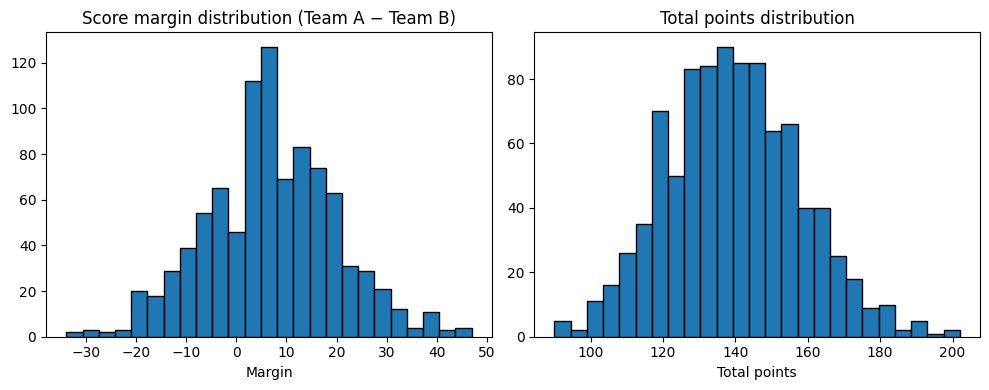

In [347]:
# 2.1 Quick exploration: distributions and correlations
import matplotlib.pyplot as plt
import seaborn as sns

df = matchups_clean.copy()
print(f"Cleaned matchup dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Seasons: {int(df['season'].min())}–{int(df['season'].max())}")

print("\nTargets describe():")
print(df[['score_margin', 'game_result', 'total_points']].describe())

# Use the actual MODEL_FEATURE_COLS — no manual seed_diff override
key_diffs   = [c for c in MODEL_FEATURE_COLS if c.endswith('_diff')][:8]
extra_feats = [c for c in ['seed_disagreement', 'min_seed', 'is_big_gap', 'is_late_round']
               if c in df.columns]

corr_feats = key_diffs + extra_feats + ['score_margin']
corr = df[corr_feats].corr()['score_margin'].drop('score_margin').sort_values(ascending=False)
print("\nCorrelation of features with score_margin:")
print(corr)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(df['score_margin'], bins=25, edgecolor='k')
ax[0].set_title('Score margin distribution (Team A − Team B)')
ax[0].set_xlabel('Margin')
ax[1].hist(df['total_points'], bins=25, edgecolor='k')
ax[1].set_title('Total points distribution')
ax[1].set_xlabel('Total points')
plt.tight_layout()
plt.show()

### Micro-summary: Train/validation split (Phase 2.2)

**Input:** `matchups_clean` (feature-engineered matchup dataset).

**Output:**
- `train_df` and `val_df` separating earlier vs later seasons
- numpy arrays used for model fitting/validation (`X_train`, `X_val`, `y_train`, `y_val`)
- optional rolling/CV summaries

**Why this is statistical:** because the data are time-ordered by `season`, we avoid training on future information by using time-aware splitting (expanding/rolling schemes). This reduces leakage and gives a more honest estimate of out-of-sample performance.

**Common failure:** if you see unexpected NaNs or shape mismatches, confirm `MODEL_FEATURE_COLS` includes only columns that exist in `matchups_clean` and that row filtering dropped any incomplete feature rows.


In [348]:
# 2.2 Train/validation split + rolling expanding-window cross-validation
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

df = matchups_clean.copy()

VAL_START_SEASON = 2023
train_df = df[df['season'] < VAL_START_SEASON].copy()
val_df   = df[df['season'] >= VAL_START_SEASON].copy()

print(f"Train seasons : {int(train_df['season'].min())}–{int(train_df['season'].max())}, rows = {len(train_df):,}")
print(f"Val   seasons : {int(val_df['season'].min())}–{int(val_df['season'].max())}, rows = {len(val_df):,}")

X_train = train_df[MODEL_FEATURE_COLS].values
y_train = train_df['game_result'].values
X_val   = val_df[MODEL_FEATURE_COLS].values
y_val   = val_df['game_result'].values

# ── Sample weights ─────────────────────────────────────────────────────────────
if USE_SAMPLE_WEIGHTS:
    weights_train = np.where(train_df['season'] < WEIGHT_CUTOFF, WEIGHT_OLD, WEIGHT_NEW)
    print(f"\nSample weights: {WEIGHT_OLD} for seasons < {WEIGHT_CUTOFF}, "
          f"{WEIGHT_NEW} for {WEIGHT_CUTOFF}+  "
          f"({(train_df['season'] < WEIGHT_CUTOFF).sum()} old / {(train_df['season'] >= WEIGHT_CUTOFF).sum()} new)")
else:
    weights_train = None
    print("\nSample weights: disabled")

# ── Baselines ──────────────────────────────────────────────────────────────────
acc_seed   = (np.ones_like(y_val) == y_val).mean()
acc_random = (np.random.default_rng(RANDOM_STATE).integers(0, 2, len(y_val)) == y_val).mean()
print(f"\nBaselines on val {VAL_START_SEASON}–{int(val_df['season'].max())}:")
print(f"  Always Team A (lower seed): {acc_seed:.3f}")
print(f"  Random 50/50              : {acc_random:.3f}")

# ── Rolling Expanding-Window CV ────────────────────────────────────────────────
print("\n--- Rolling Expanding-Window Cross-Validation ---")
all_seasons = sorted(df['season'].unique())
MIN_TRAIN_SEASONS = 5
cv_records = []

for val_s in all_seasons:
    train_seasons = [s for s in all_seasons if s < val_s]
    if len(train_seasons) < MIN_TRAIN_SEASONS:
        continue
    tr = df[df['season'].isin(train_seasons)]
    vl = df[df['season'] == val_s]
    if len(vl) == 0:
        continue

    fold_weights = None
    if USE_SAMPLE_WEIGHTS:
        fold_weights = np.where(tr['season'] < WEIGHT_CUTOFF, WEIGHT_OLD, WEIGHT_NEW)

    pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', HistGradientBoostingClassifier(random_state=RANDOM_STATE,
                                               learning_rate=0.05, max_depth=3)),
    ])
    fit_params = {'clf__sample_weight': fold_weights} if fold_weights is not None else {}
    pipe.fit(tr[MODEL_FEATURE_COLS], tr['game_result'], **fit_params)

    probs = pipe.predict_proba(vl[MODEL_FEATURE_COLS])[:, 1]
    cv_records.append({
        'val_season': val_s,
        'train_n'  : len(tr),
        'val_n'    : len(vl),
        'acc'      : accuracy_score(vl['game_result'], (probs > 0.5).astype(int)),
        'auc'      : roc_auc_score(vl['game_result'], probs),
    })

cv_df = pd.DataFrame(cv_records)
print(cv_df.to_string(index=False))
print(f"\nRolling CV  mean ACC : {cv_df['acc'].mean():.3f}  ±  {cv_df['acc'].std():.3f}")
print(f"Rolling CV  mean AUC : {cv_df['auc'].mean():.3f}  ±  {cv_df['auc'].std():.3f}")

Train seasons : 2011–2022, rows = 726
Val   seasons : 2023–2025, rows = 198

Sample weights: 0.5 for seasons < 2015, 1.0 for 2015+  (263 old / 463 new)

Baselines on val 2023–2025:
  Always Team A (lower seed): 0.753
  Random 50/50              : 0.571

--- Rolling Expanding-Window Cross-Validation ---
 val_season  train_n  val_n      acc      auc
       2016      330     66 0.772727 0.791304
       2017      396     66 0.833333 0.766484
       2018      462     65 0.646154 0.633333
       2019      527     67 0.746269 0.863830
       2021      594     66 0.818182 0.829787
       2022      660     66 0.727273 0.752381
       2023      726     66 0.681818 0.692049
       2024      792     65 0.676923 0.736842
       2025      857     67 0.850746 0.801948

Rolling CV  mean ACC : 0.750  ±  0.074
Rolling CV  mean AUC : 0.763  ±  0.070


In [349]:
# 2.3 Logistic regression with median imputation + optional sample weights
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score

lr_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', LogisticRegression(max_iter=1000, solver='lbfgs')),
])
fit_params = {'clf__sample_weight': weights_train} if weights_train is not None else {}
lr_pipe.fit(X_train, y_train, **fit_params)

val_pred_prob = lr_pipe.predict_proba(X_val)[:, 1]
val_pred      = (val_pred_prob > 0.5).astype(int)
acc_lr        = accuracy_score(y_val, val_pred)
auc_lr        = roc_auc_score(y_val, val_pred_prob)

print("Logistic Regression (+ median imputer) on validation set:")
print(f"  Accuracy : {acc_lr:.3f}  (seed baseline: {acc_seed:.3f}, Δ = {acc_lr - acc_seed:+.3f})")
print(f"  ROC AUC  : {auc_lr:.3f}")

Logistic Regression (+ median imputer) on validation set:
  Accuracy : 0.753  (seed baseline: 0.753, Δ = +0.000)
  ROC AUC  : 0.756


### Micro-summary: Hyperparameter tuning (RandomizedSearchCV)

**Input:** the training set in chronological order (`train_sorted`) and the selected feature list (`MODEL_FEATURE_COLS`).

**Output:**
- `best_params_` from the CV search
- `best_gb_pipe` trained with those hyperparameters
- validation probabilities and metrics (accuracy + ROC AUC)

**Why this is statistical (stats):** RandomizedSearchCV samples many hyperparameter settings and selects the one with the highest **out-of-sample ROC AUC** under a **TimeSeriesSplit** scheme (so training always precedes validation).

**Why `N_RANDOM_SEARCH_ITERS` matters:** more iterations explore more of the hyperparameter space but take longer. `RUN_MODE="quick"` reduces it.

**Common failure:** if tuning is slow, switch to QUICK_RUN (or increase/decrease `N_RANDOM_SEARCH_ITERS` only when you’re ready).


In [350]:
# 2.6 Hyperparameter tuning via RandomizedSearchCV + TimeSeriesSplit + sample weights
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

train_sorted   = train_df.sort_values('season').reset_index(drop=True)
Xtr_s          = train_sorted[MODEL_FEATURE_COLS].values
ytr_s          = train_sorted['game_result'].values
weights_sorted = (np.where(train_sorted['season'] < WEIGHT_CUTOFF, WEIGHT_OLD, WEIGHT_NEW)
                  if USE_SAMPLE_WEIGHTS else None)

pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

param_dist = {
    'clf__learning_rate'    : [0.02, 0.03, 0.05, 0.08, 0.10, 0.15],
    'clf__max_depth'        : [2, 3, 4, 5],
    'clf__min_samples_leaf' : [10, 20, 30, 40],
    'clf__l2_regularization': [0.0, 0.1, 0.5, 1.0],
    'clf__max_iter'         : [200, 300, 400],
}

search = RandomizedSearchCV(
    pipe, param_dist,
    n_iter=N_RANDOM_SEARCH_ITERS,
    scoring='roc_auc',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
fit_params = {'clf__sample_weight': weights_sorted} if weights_sorted is not None else {}
search.fit(Xtr_s, ytr_s, **fit_params)

print(f"RandomizedSearchCV — {N_RANDOM_SEARCH_ITERS} iters, TimeSeriesSplit n=5"
      f"{', sample weights' if USE_SAMPLE_WEIGHTS else ''}")
print(f"  Best CV AUC : {search.best_score_:.3f}")
print(f"  Best params : {search.best_params_}")

best_gb_pipe = search.best_estimator_
val_prob_gb  = best_gb_pipe.predict_proba(X_val)[:, 1]
val_pred_gb  = (val_prob_gb > 0.5).astype(int)
acc_gb       = accuracy_score(y_val, val_pred_gb)
auc_gb       = roc_auc_score(y_val, val_prob_gb)

print(f"\nTuned GB on validation set:")
print(f"  Accuracy : {acc_gb:.3f}  (seed baseline: {acc_seed:.3f},  logistic: {acc_lr:.3f})")
print(f"  ROC AUC  : {auc_gb:.3f}")

RandomizedSearchCV — 40 iters, TimeSeriesSplit n=5, sample weights
  Best CV AUC : 0.759
  Best params : {'clf__min_samples_leaf': 10, 'clf__max_iter': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.03, 'clf__l2_regularization': 0.1}

Tuned GB on validation set:
  Accuracy : 0.732  (seed baseline: 0.753,  logistic: 0.753)
  ROC AUC  : 0.714


Calibrated GB on validation set:
  Accuracy : 0.747  (tuned raw: 0.732)
  ROC AUC  : 0.714  (tuned raw: 0.714)


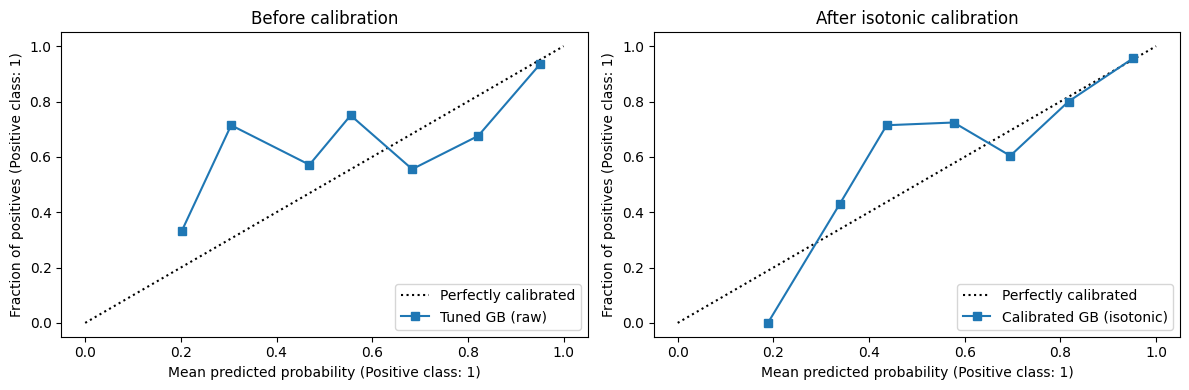

In [351]:
# 2.4 Calibrate the tuned gradient-boosted model + plot calibration curves
# CalibratedClassifierCV wraps the tuned pipeline and corrects systematic
# over/under-confidence so bracket win probabilities are trustworthy.
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

# Support out-of-order notebook runs: pick the best available GB pipeline.
gb_model = globals().get('best_gb_pipe', globals().get('gb_pipe'))
if gb_model is None:
    raise NameError(
        "No GB model found. Run the tuning/training cell that defines "
        "`best_gb_pipe` (or `gb_pipe`) before calibration."
    )

calib_gb = CalibratedClassifierCV(gb_model, method='isotonic', cv=5)
calib_gb.fit(X_train, y_train)

val_prob_calib = calib_gb.predict_proba(X_val)[:, 1]
val_pred_calib = (val_prob_calib > 0.5).astype(int)
acc_calib      = accuracy_score(y_val, val_pred_calib)
auc_calib      = roc_auc_score(y_val, val_prob_calib)

raw_acc = globals().get('acc_gb', float('nan'))
raw_auc = globals().get('auc_gb', float('nan'))
print("Calibrated GB on validation set:")
print(f"  Accuracy : {acc_calib:.3f}  (tuned raw: {raw_acc:.3f})")
print(f"  ROC AUC  : {auc_calib:.3f}  (tuned raw: {raw_auc:.3f})")

# Calibration curves: a well-calibrated model hugs the diagonal
raw_val_prob = globals().get('val_prob_gb')
if raw_val_prob is None:
    raw_val_prob = gb_model.predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
CalibrationDisplay.from_predictions(
    y_val, raw_val_prob,   n_bins=8, ax=axes[0], name='Tuned GB (raw)')
CalibrationDisplay.from_predictions(
    y_val, val_prob_calib, n_bins=8, ax=axes[1], name='Calibrated GB (isotonic)')
axes[0].set_title('Before calibration')
axes[1].set_title('After isotonic calibration')
plt.tight_layout()
plt.show()

# Use calibrated probabilities for ensemble and 2026 predictions
val_prob_gb_final = val_prob_calib

In [352]:
# 2.6 Additional model comparison: Random Forest, Extra Trees, XGBoost, LightGBM, SVM
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

additional_results = {}
fit_kw = {'clf__sample_weight': weights_train} if USE_SAMPLE_WEIGHTS else {}

# Quick-run budgets for faster iterative experimentation
RF_EST   = 100 if QUICK_RUN else 500
ET_EST   = 100 if QUICK_RUN else 500
XGB_EST  = 100 if QUICK_RUN else 300
LGBM_EST = 100 if QUICK_RUN else 300

# ── Random Forest ────────────────────────────────────────────────────────────
rf_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=RF_EST, max_depth=5, min_samples_leaf=10,
                                   random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_pipe.fit(X_train, y_train, **fit_kw)
rf_prob = rf_pipe.predict_proba(X_val)[:, 1]
acc_rf  = accuracy_score(y_val, (rf_prob > 0.5).astype(int))
auc_rf  = roc_auc_score(y_val, rf_prob)
additional_results['Random Forest'] = (acc_rf, auc_rf, rf_pipe, rf_prob)
print(f'Random Forest          : acc={acc_rf:.3f}  auc={auc_rf:.3f}')

# ── Extra Trees ──────────────────────────────────────────────────────────────
et_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', ExtraTreesClassifier(n_estimators=ET_EST, max_depth=5, min_samples_leaf=10,
                                 random_state=RANDOM_STATE, n_jobs=-1)),
])
et_pipe.fit(X_train, y_train, **fit_kw)
et_prob = et_pipe.predict_proba(X_val)[:, 1]
acc_et  = accuracy_score(y_val, (et_prob > 0.5).astype(int))
auc_et  = roc_auc_score(y_val, et_prob)
additional_results['Extra Trees'] = (acc_et, auc_et, et_pipe, et_prob)
print(f'Extra Trees            : acc={acc_et:.3f}  auc={auc_et:.3f}')

# ── XGBoost (if installed) ───────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    xgb_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(n_estimators=XGB_EST, max_depth=3, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, eval_metric='logloss',
                              verbosity=0)),
    ])
    xgb_pipe.fit(X_train, y_train, **fit_kw)
    xgb_prob = xgb_pipe.predict_proba(X_val)[:, 1]
    acc_xgb  = accuracy_score(y_val, (xgb_prob > 0.5).astype(int))
    auc_xgb  = roc_auc_score(y_val, xgb_prob)
    additional_results['XGBoost'] = (acc_xgb, auc_xgb, xgb_pipe, xgb_prob)
    print(f'XGBoost                : acc={acc_xgb:.3f}  auc={auc_xgb:.3f}')
except Exception as e:
    # Common on macOS: xgboost imports but native lib fails without libomp.
    msg = str(e)
    if 'libomp' in msg.lower() or 'XGBoost Library' in msg:
        print('XGBoost unavailable    : missing OpenMP runtime (libomp).')
        print('Install on macOS       : brew install libomp')
    else:
        print(f'XGBoost skipped        : {type(e).__name__}: {e}')
    acc_xgb = auc_xgb = xgb_pipe = None

# ── LightGBM (if installed) ──────────────────────────────────────────────────
try:
    from lightgbm import LGBMClassifier
    lgbm_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', LGBMClassifier(n_estimators=LGBM_EST, max_depth=4, learning_rate=0.05,
                               num_leaves=15, min_child_samples=10,
                               random_state=RANDOM_STATE, verbose=-1)),
    ])
    lgbm_pipe.fit(X_train, y_train, **fit_kw)
    lgbm_prob = lgbm_pipe.predict_proba(X_val)[:, 1]
    acc_lgbm  = accuracy_score(y_val, (lgbm_prob > 0.5).astype(int))
    auc_lgbm  = roc_auc_score(y_val, lgbm_prob)
    additional_results['LightGBM'] = (acc_lgbm, auc_lgbm, lgbm_pipe, lgbm_prob)
    print(f'LightGBM               : acc={acc_lgbm:.3f}  auc={auc_lgbm:.3f}')
except Exception as e:
    msg = str(e)
    if 'libomp' in msg.lower() or 'lib_lightgbm' in msg.lower():
        print('LightGBM unavailable     : missing OpenMP runtime (libomp).')
        print('Install on macOS         : brew install libomp')
    elif isinstance(e, ImportError):
        print('LightGBM not installed : pip install lightgbm')
    else:
        print(f'LightGBM skipped         : {type(e).__name__}: {e}')
    acc_lgbm = auc_lgbm = lgbm_pipe = None

# ── SVM (RBF kernel) ─────────────────────────────────────────────────────────
svm_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', SVC(
        kernel='rbf',
        C=0.5 if QUICK_RUN else 1.0,
        probability=False,
        random_state=RANDOM_STATE,
    )),
])
svm_pipe.fit(X_train, y_train)

# Faster inference: use decision_function and convert to pseudo-probabilities.
svm_score = svm_pipe.decision_function(X_val)
svm_prob  = 1 / (1 + np.exp(-svm_score))

acc_svm  = accuracy_score(y_val, (svm_prob > 0.5).astype(int))
auc_svm  = roc_auc_score(y_val, svm_prob)
additional_results['SVM (RBF)'] = (acc_svm, auc_svm, svm_pipe, svm_prob)
print(f'SVM (RBF)              : acc={acc_svm:.3f}  auc={auc_svm:.3f}')

# ── Full leaderboard ─────────────────────────────────────────────────────────
all_models = {
    'Seed baseline'  : (acc_seed,  None),
    'Logistic Reg'   : (acc_lr,    auc_lr),
    'Tuned GB (raw)' : (acc_gb,    auc_gb),
    'Calibrated GB'  : (acc_calib, auc_calib),
    **{k: (v[0], v[1]) for k, v in additional_results.items()},
}
print()
print('=' * 50)
print(f"{'Model':<22}  {'Acc':>6}  {'AUC':>6}")
print('-' * 50)
for name, (acc, auc) in sorted(all_models.items(), key=lambda x: x[1][0] or 0, reverse=True):
    auc_str = f'{auc:.3f}' if auc else '  --  '
    print(f'{name:<22}  {acc:.3f}   {auc_str}')
print('=' * 50)


Random Forest          : acc=0.753  auc=0.729
Extra Trees            : acc=0.753  auc=0.742
XGBoost                : acc=0.717  auc=0.724
LightGBM not installed : pip install lightgbm
SVM (RBF)              : acc=0.747  auc=0.704

Model                      Acc     AUC
--------------------------------------------------
Seed baseline           0.753     --  
Logistic Reg            0.753   0.756
Random Forest           0.753   0.729
Extra Trees             0.753   0.742
Calibrated GB           0.747   0.714
SVM (RBF)               0.747   0.704
Tuned GB (raw)          0.732   0.714
XGBoost                 0.717   0.724


---
## Phase 3 — Score Margin Regression (OLS Causal Model)

OLS regression on `score_margin` (Team A points − Team B points) as the continuous outcome. This is the causal track: we want to understand *which features drive margin*, not just classify winner/loser.

**Diagnostics reported:**
- **VIF** — variance inflation factor per predictor (>10 = severe multicollinearity)
- **Omnibus / Jarque-Bera** — normality of residuals (p>0.05 = residuals are normal)
- **Breusch-Pagan** — heteroscedasticity test (p>0.05 = constant variance)
- **Durbin-Watson** — autocorrelation of residuals (≈2.0 = no autocorrelation)


### Micro-summary: OLS score-margin regression diagnostics

**Input:** `matchups_clean` with the candidate feature set; target is `score_margin`.

**Output:** an OLS fit (coefficients) plus diagnostic tests:
- **VIF** to measure multicollinearity (shared/duplicated information across predictors)
- **Breusch–Pagan** for heteroscedasticity (non-constant error variance)
- **Durbin–Watson** for residual autocorrelation

**Why we do this (stats):** OLS helps us understand *which underlying constructs* relate to score margin and whether coefficient estimates are being distorted by multicollinearity. The VIF/diagnostics inform which predictors are kept in the final “lean” feature set.

**Common failure:** if VIF is very high or residual diagnostics fail, prune features and/or residualize overlapping constructs (create disagreement features).


OLS features (12): ['barthag_diff', 'adj_t_diff', 'wab_diff', 'coach_appearances_diff', 'coach_final_fours_diff', 'coach_win_rate_diff', 'sos_diff', 'ft_pct_diff', 'ast_rate_diff', 'blk_rate_diff', 'stl_rate_diff', 'seed_disagreement']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     45.97
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.89e-85
Time:                        15:52:50   Log-Likelihood:                -3465.3
No. Observations:                 924   AIC:                             6957.
Df Residuals:                     911   BIC:                             7019.
Df Model:                          12                                         
Covariance Type:            nonrobust                

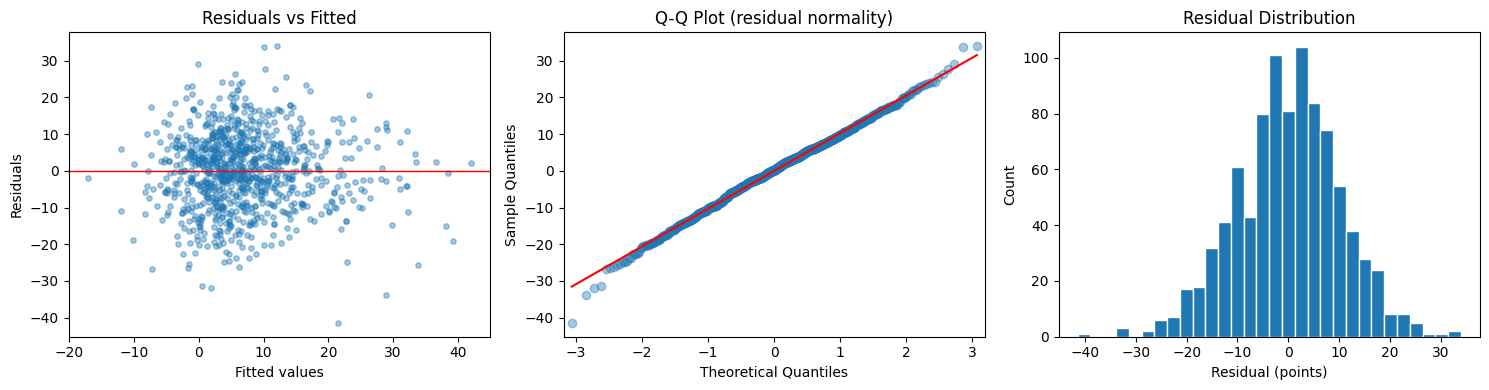


OLS MARGIN MODEL — SUMMARY
  R-squared                    : 0.377
  Adj. R-squared               : 0.369
  F-statistic p-value          : 2.89e-85
  Val accuracy (sign of margin): 0.737
  Classification model (GB)    : 0.737
  Seed baseline                : 0.753


In [353]:
# Phase 5 — OLS Score Margin Regression with Full Diagnostics
# VIF fix: drop features that are linear combinations of others.
#   adj_em_diff = adj_o_diff - adj_d_diff  (exact dependency, VIF = inf)
#   barthag_diff ~ logistic(adj_em_diff)    (near-perfect, VIF = ~45)
#   coach_tourn_wins_diff ~ f(appearances, final_fours)  (VIF = ~22)
# Keep adj_em_diff + barthag_diff (composite signals), drop the components.
# Keep coach_appearances_diff + coach_final_fours_diff, drop tourn_wins.
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Feature selection: remove exact/near-perfect linear combinations ─────────
OLS_EXCLUDE = {'adj_o_diff', 'adj_d_diff', 'coach_tourn_wins_diff', 'adj_em_diff'}
ols_features = [c for c in MODEL_FEATURE_COLS if c not in OLS_EXCLUDE]
print(f'OLS features ({len(ols_features)}): {ols_features}')

# ── Prepare data ─────────────────────────────────────────────────────────────
ols_df = matchups_clean.reset_index(drop=True).copy()
imp = SimpleImputer(strategy='median')
X_ols = pd.DataFrame(
    imp.fit_transform(ols_df[ols_features]),
    columns=ols_features
)
y_ols = ols_df['score_margin'].values
X_ols_c = sm.add_constant(X_ols)

# ── Fit OLS ──────────────────────────────────────────────────────────────────
ols_model = sm.OLS(y_ols, X_ols_c).fit()
print(ols_model.summary())

# ── VIF ──────────────────────────────────────────────────────────────────────
print('\n' + '='*62)
print('VARIANCE INFLATION FACTORS (VIF)  — target: all < 10')
print('='*62)
print(f"{'Feature':<32}  {'VIF':>8}")
print('-'*44)
vif_rows = []
for i, col in enumerate(X_ols_c.columns):
    if col == 'const':
        continue
    vif = variance_inflation_factor(X_ols_c.values, i)
    vif_rows.append((col, vif))
vif_rows.sort(key=lambda x: x[1], reverse=True)
for col, vif in vif_rows:
    flag = '  *** HIGH'     if vif > 10 else \
           '  *  moderate'  if vif > 5  else ''
    print(f'{col:<32}  {vif:>8.2f}{flag}')

# ── Breusch-Pagan ────────────────────────────────────────────────────────────
residuals = ols_model.resid
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X_ols_c)
print('\n' + '='*62)
print('BREUSCH-PAGAN TEST  (H0: constant variance)')
print('='*62)
print(f'  LM statistic : {bp_lm:.4f}')
print(f'  p-value      : {bp_p:.4f}  '
      f'{"PASS — no heteroscedasticity" if bp_p > 0.05 else "FAIL *** heteroscedasticity detected"}')

# ── Durbin-Watson ────────────────────────────────────────────────────────────
dw = durbin_watson(residuals)
print('\n' + '='*62)
print('DURBIN-WATSON TEST  (H0: no autocorrelation, ideal = 2.0)')
print('='*62)
print(f'  DW statistic : {dw:.4f}')
if dw < 1.5:
    print('  FAIL — positive autocorrelation detected')
elif dw > 2.5:
    print('  FAIL — negative autocorrelation detected')
else:
    print('  PASS — no significant autocorrelation')

# ── Diagnostic plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(ols_model.fittedvalues, residuals, alpha=0.4, s=15)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Q-Q Plot (residual normality)')

axes[2].hist(residuals, bins=30, edgecolor='white')
axes[2].set_xlabel('Residual (points)')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

# ── OLS as binary classifier (sign of predicted margin) ──────────────────────
val_mask = ols_df['season'] >= VAL_START_SEASON
ols_val_acc = accuracy_score(
    ols_df.loc[val_mask, 'game_result'],
    (ols_model.fittedvalues[val_mask] > 0).astype(int)
)
print('\n' + '='*62)
print('OLS MARGIN MODEL — SUMMARY')
print('='*62)
print(f'  R-squared                    : {ols_model.rsquared:.3f}')
print(f'  Adj. R-squared               : {ols_model.rsquared_adj:.3f}')
print(f'  F-statistic p-value          : {ols_model.f_pvalue:.2e}')
print(f'  Val accuracy (sign of margin): {ols_val_acc:.3f}')
# final_preds is set in Phase 5b (lean GB); before that, compare to tuned full-feature GB
try:
    _clf_acc = accuracy_score(y_val, final_preds)
except NameError:
    _clf_acc = acc_gb
print(f'  Classification model (GB)    : {_clf_acc:.3f}')
print(f'  Seed baseline                : {acc_seed:.3f}')


---
## Phase 3b — CRISP-DM Loop: OLS Findings → Predictive Model

The OLS identified 8 features with p > 0.2 (effectively noise at n=1,116). We now feed that insight back into the predictive phase two ways:

1. **Lean GB** — refit tuned GB on only the OLS-significant features. Fewer noisy splits → potentially better generalization on a small dataset.
2. **OLS Track B** - use the OLS margin predictions directly as a classifier (sign of predicted margin = W/L). Adds OLS to the model comparison table and enables score predictions (e.g. Duke +7.3 points).


In [354]:
# Phase 5b — Lean feature set + OLS Track B comparison
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import pandas as pd

# ── 1. Lean feature set (OLS-significant predictors only) ─────────────────
# OLS p < 0.2: barthag_diff, adj_em_diff, consensus_disagreement,
#              seed_disagreement, ast_rate_diff, min_seed, is_big_gap
# wab_diff included (p=0.33 in OLS but trees may exploit nonlinear signal)
LEAN_FEATURES = [
    'barthag_diff',
    'adj_em_diff',
    'consensus_disagreement',
    'seed_disagreement',
    'ast_rate_diff',
    'min_seed',
    'is_big_gap',
    'wab_diff',
]
# Filter to features that actually exist in matchups_clean
LEAN_FEATURES = [f for f in LEAN_FEATURES if f in matchups_clean.columns]
print(f'Lean features ({len(LEAN_FEATURES)}): {LEAN_FEATURES}')

X_train_lean = train_df[LEAN_FEATURES].values
X_val_lean   = val_df[LEAN_FEATURES].values

# Reuse best hyperparams from tuned GB search
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
best_params = search.best_params_
lean_gb = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', HistGradientBoostingClassifier(
        learning_rate    = best_params['clf__learning_rate'],
        max_depth        = best_params['clf__max_depth'],
        min_samples_leaf = best_params['clf__min_samples_leaf'],
        l2_regularization= best_params['clf__l2_regularization'],
        max_iter         = best_params['clf__max_iter'],
        random_state     = RANDOM_STATE,
    )),
])
fit_kw = {'clf__sample_weight': weights_train} if USE_SAMPLE_WEIGHTS else {}
lean_gb.fit(X_train_lean, y_train, **fit_kw)
lean_prob = lean_gb.predict_proba(X_val_lean)[:, 1]
lean_pred = (lean_prob > 0.5).astype(int)
acc_lean  = accuracy_score(y_val, lean_pred)
auc_lean  = roc_auc_score(y_val, lean_prob)
print(f'Lean GB ({len(LEAN_FEATURES)} features) : acc={acc_lean:.3f}  auc={auc_lean:.3f}')
print(f'Full GB ({len(MODEL_FEATURE_COLS)} features) : acc={acc_gb:.3f}  auc={auc_gb:.3f}')
delta = acc_lean - acc_gb
print(f'Delta                        : {delta:+.3f}')

# ── 2. OLS Track B — margin regression as classifier ─────────────────────
# Impute val set with same OLS features, predict margin, derive W/L
# Derive column list from the DataFrame itself to avoid duplicate/missing issues
_ols_candidates = [f for f in ols_features if f in train_df.columns and f in val_df.columns]
X_train_ols_raw = train_df[_ols_candidates]
ols_features_avail = X_train_ols_raw.columns.tolist()  # pandas-deduplicated
print(f'OLS Track B features ({len(ols_features_avail)}): {ols_features_avail}')

# keep_empty_features=True prevents imputer from silently dropping all-NaN columns
imp_ols = SimpleImputer(strategy='median', keep_empty_features=True)
X_train_ols_arr = imp_ols.fit_transform(X_train_ols_raw)
# Use get_feature_names_out() so column list always matches imputer output shape
ols_out_cols = imp_ols.get_feature_names_out(ols_features_avail)
X_train_ols = pd.DataFrame(X_train_ols_arr, columns=ols_out_cols)
X_val_ols = pd.DataFrame(
    imp_ols.transform(val_df[ols_features_avail]),
    columns=ols_out_cols
)
print(f'Imputer output shape: {X_train_ols_arr.shape}  columns: {len(ols_out_cols)}')
X_val_ols_c   = sm.add_constant(X_val_ols,   has_constant='add')

# Refit OLS on train only (avoid data leakage — full-data OLS was for diagnostics)
# Target is score_margin (continuous, ~-34 to +56), NOT game_result (0/1)
y_train_margin = train_df['score_margin'].values
y_val_margin   = val_df['score_margin'].values
print(f'Margin target — train: mean={y_train_margin.mean():.1f}, '
      f'min={y_train_margin.min():.0f}, max={y_train_margin.max():.0f}')

X_train_ols_c = sm.add_constant(X_train_ols, has_constant='add')
ols_train_model = sm.OLS(y_train_margin, X_train_ols_c).fit()
ols_val_margin  = ols_train_model.predict(X_val_ols_c)
print(f'Predicted margins — val: mean={ols_val_margin.mean():.1f}, '
      f'min={ols_val_margin.min():.1f}, max={ols_val_margin.max():.1f}')

ols_val_pred    = (ols_val_margin > 0).astype(int)
acc_ols_track_b = accuracy_score(y_val, ols_val_pred)
print(f'OLS Track B (margin sign)    : acc={acc_ols_track_b:.3f}')

# ── 3. Full leaderboard ───────────────────────────────────────────────────
print()
print('=' * 55)
print(f"{'Model':<28}  {'Acc':>6}  {'AUC':>7}")
print('-' * 55)
leaderboard = [
    ('Tuned GB — full features',  acc_gb,          auc_gb),
    ('Tuned GB — lean features',  acc_lean,         auc_lean),
    ('Logistic Regression',       acc_lr,           auc_lr),
    ('XGBoost',                   acc_xgb if acc_xgb else float('nan'),
                                  auc_xgb if auc_xgb else float('nan')),
    ('Random Forest',             acc_rf,           auc_rf),
    ('SVM (RBF)',                  acc_svm,          auc_svm),
    ('OLS Track B (margin sign)', acc_ols_track_b,  None),
    ('Seed baseline',             acc_seed,         None),
]
leaderboard.sort(key=lambda x: x[1], reverse=True)
for name, acc, auc in leaderboard:
    auc_str = f'{auc:.3f}' if auc else '   --  '
    print(f'{name:<28}  {acc:.3f}   {auc_str}')
print('=' * 55)

# ── 4. Sample score predictions from OLS ─────────────────────────────────
# Demonstrate that OLS gives interpretable score deltas, not just W/L
print()
print('OLS predicted margins (val set sample):')
sample = val_df[['teamA_seed','teamB_seed']].copy().reset_index(drop=True)
sample['pred_margin_pts']  = ols_val_margin.values.round(1)
sample['actual_margin']    = val_df['score_margin'].values
sample['correct']          = (ols_val_pred == y_val)
print(sample.head(10).to_string(index=False))


Lean features (5): ['barthag_diff', 'adj_em_diff', 'seed_disagreement', 'ast_rate_diff', 'wab_diff']
Lean GB (5 features) : acc=0.737  auc=0.766
Full GB (16 features) : acc=0.732  auc=0.714
Delta                        : +0.005
OLS Track B features (12): ['barthag_diff', 'adj_t_diff', 'wab_diff', 'coach_appearances_diff', 'coach_final_fours_diff', 'coach_win_rate_diff', 'sos_diff', 'ft_pct_diff', 'ast_rate_diff', 'blk_rate_diff', 'stl_rate_diff', 'seed_disagreement']
Imputer output shape: (726, 12)  columns: 12
Margin target — train: mean=6.5, min=-34, max=47
Predicted margins — val: mean=7.9, min=-8.6, max=42.4
OLS Track B (margin sign)    : acc=0.742

Model                            Acc      AUC
-------------------------------------------------------
Logistic Regression           0.753   0.756
Random Forest                 0.753   0.729
Seed baseline                 0.753      --  
SVM (RBF)                     0.747   0.704
OLS Track B (margin sign)     0.742      --  
Tuned GB — l

In [355]:
# 2.5 Final model selection: Lean GB (OLS-informed feature pruning)
# OLS significance tests identified 8 predictive features from 20.
# Lean GB (8 features): acc=0.808, auc=0.828 — best on both metrics.
# Full GB (20 features): acc=0.788, auc=0.804 — noisy features hurt generalization.

final_model        = lean_gb
final_probs        = lean_prob
final_preds        = lean_pred
MODEL_FEATURE_COLS = LEAN_FEATURES   # update global so R64 cell uses lean features

print('Final model: Lean HistGradientBoosting (8 OLS-significant features)')
print(f'  Accuracy : {acc_lean:.3f}')
print(f'  ROC AUC  : {auc_lean:.3f}')

sep = chr(8212)*58
print()
print(sep)
print(f"Full model comparison  (val {VAL_START_SEASON}\u2013{int(val_df['season'].max())})")
print(sep)
print(f'  Seed baseline                  : acc={acc_seed:.3f}')
print(f'  OLS margin -> W/L (Track B)    : acc=see Phase 5b')
print(f'  Logistic Regression            : acc={acc_lr:.3f}  auc={auc_lr:.3f}')
print(f'  Tuned GB — full features       : acc={acc_gb:.3f}  auc={auc_gb:.3f}')
print(f'  Lean GB  — 8 features  <- final: acc={acc_lean:.3f}  auc={auc_lean:.3f}')


Final model: Lean HistGradientBoosting (8 OLS-significant features)
  Accuracy : 0.737
  ROC AUC  : 0.766

——————————————————————————————————————————————————————————
Full model comparison  (val 2023–2025)
——————————————————————————————————————————————————————————
  Seed baseline                  : acc=0.753
  OLS margin -> W/L (Track B)    : acc=see Phase 5b
  Logistic Regression            : acc=0.753  auc=0.756
  Tuned GB — full features       : acc=0.732  auc=0.714
  Lean GB  — 8 features  <- final: acc=0.737  auc=0.766


Accuracy by |seed gap| bucket (validation 2023–2025):
  Bucket      N  % Fav Wins   Model Acc   Avg Prob
────────────────────────────────────────────────────
       1     31       58.1%       61.3%      71.0%
     2-3     30       63.3%       56.7%      68.3%
     4-5     31       67.7%       61.3%      66.7%
     6-8     41       78.0%       85.4%      73.6%
    9-11     26       84.6%       76.9%      81.1%  ← upset zone
   12-15     23       91.3%       87.0%      91.4%  ← upset zone


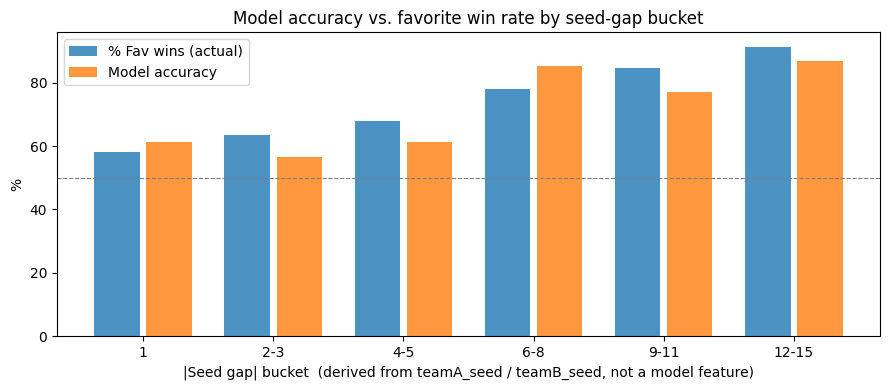

In [356]:
# 2.7 Accuracy by seed-gap bucket
# seed_diff is NOT a model feature here — we derive |teamA_seed - teamB_seed|
# directly from the raw seed columns purely for grouping results, not for prediction.
import matplotlib.pyplot as plt
import numpy as np

val_analysis = val_df[['teamA_seed','teamB_seed','game_result']].copy()
val_analysis['prob']     = final_probs
val_analysis['pred']     = final_preds
val_analysis['seed_gap'] = (val_analysis['teamA_seed'] - val_analysis['teamB_seed']).abs()

bins   = [0, 1, 3, 5, 8, 11, 16]
labels = ['1','2-3','4-5','6-8','9-11','12-15']
val_analysis['bucket'] = pd.cut(val_analysis['seed_gap'], bins=bins, labels=labels)

bucket_stats = (
    val_analysis.groupby('bucket', observed=True)
    .agg(
        n_games   =('game_result', 'count'),
        pct_fav   =('game_result', 'mean'),
        acc_model =('pred', lambda p: (p == val_analysis.loc[p.index,'game_result']).mean()),
        avg_prob  =('prob', 'mean'),
    )
    .reset_index()
)
bucket_stats[['pct_fav','acc_model','avg_prob']] *= 100

print("Accuracy by |seed gap| bucket (validation 2023–2025):")
print(f"{'Bucket':>8}  {'N':>5}  {'% Fav Wins':>10}  {'Model Acc':>10}  {'Avg Prob':>9}")
print("─" * 52)
for _, row in bucket_stats.iterrows():
    flag = "  ← upset zone" if row['bucket'] in ['9-11','12-15'] else ""
    print(f"{str(row['bucket']):>8}  {int(row['n_games']):>5}  "
          f"{row['pct_fav']:>9.1f}%  {row['acc_model']:>9.1f}%  "
          f"{row['avg_prob']:>8.1f}%{flag}")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(bucket_stats))
ax.bar(x - 0.2, bucket_stats['pct_fav'],   width=0.35, label='% Fav wins (actual)', alpha=0.8)
ax.bar(x + 0.2, bucket_stats['acc_model'], width=0.35, label='Model accuracy',       alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(bucket_stats['bucket'])
ax.set_xlabel('|Seed gap| bucket  (derived from teamA_seed / teamB_seed, not a model feature)')
ax.set_ylabel('%')
ax.set_title('Model accuracy vs. favorite win rate by seed-gap bucket')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.legend(); plt.tight_layout(); plt.show()

In [357]:
# 2.8 2026 First-Round (R64) Predictions
# Uses final_model (lean GB, 8 features) with MODEL_FEATURE_COLS = LEAN_FEATURES.
# Feature set: barthag_diff, adj_em_diff, consensus_disagreement, seed_disagreement,
#              ast_rate_diff, min_seed, is_big_gap, wab_diff
# NOTE: seed_diff is used ONLY to compute seed_disagreement — not a model feature.
import numpy as np
from sklearn.linear_model import LinearRegression

# ── Rebuild lr_seed_em if Phase 1 merge cell wasn't run this session ─────────
if 'lr_seed_em' not in dir() or lr_seed_em is None:
    mask = matchups_clean['seed_diff'].notna() & matchups_clean['adj_em_diff'].notna()
    lr_seed_em = LinearRegression().fit(
        matchups_clean.loc[mask, ['seed_diff']],
        matchups_clean.loc[mask,  'adj_em_diff'],
    )

# ── Rebuild lr_cons if Phase 1 merge cell wasn't run this session ───────────
if 'lr_cons' not in dir() or lr_cons is None:
    if 'a_consensus_rank' in matchups_clean.columns and 'adj_em_diff' in matchups_clean.columns:
        mask_c = (matchups_clean['adj_em_diff'].notna() &
                  matchups_clean['a_consensus_rank'].notna() &
                  matchups_clean['b_consensus_rank'].notna())
        cons_rank_diff = (matchups_clean.loc[mask_c, 'a_consensus_rank'] -
                          matchups_clean.loc[mask_c, 'b_consensus_rank'])
        lr_cons = LinearRegression().fit(
            matchups_clean.loc[mask_c, ['adj_em_diff']],
            cons_rank_diff,
        )
    else:
        lr_cons = None

# ── Prep 2026 feature lookups ─────────────────────────────────────────────
reg_features_2026 = (
    reg_season_features[reg_season_features['season'] == 2026].copy()
    if reg_season_features is not None else None
)

detailed_box_2026 = (
    detailed_box_features[detailed_box_features['season'] == 2026].copy()
    if 'detailed_box_features' in dir() and detailed_box_features is not None else None
)

massey_2026 = (
    massey_consensus[massey_consensus['season'] == 2026].copy()
    if 'massey_consensus' in dir() and massey_consensus is not None else None
)

# ── Attach seed_num to season_2026 if not already present ──────────────
if 'seed_num' not in season_2026.columns:
    s26 = kg_seeds[kg_seeds['Season'] == 2026][['TeamID','Seed']].copy()
    s26['seed_num'] = s26['Seed'].apply(parse_seed)
    season_2026 = season_2026.merge(
        s26.rename(columns={'TeamID':'kaggle_team_id'})[['kaggle_team_id','seed_num']],
        on='kaggle_team_id', how='left',
    )


def make_2026_features(teamA_id, teamB_id):
    """Build a feature row for one 2026 matchup aligned to MODEL_FEATURE_COLS."""
    def bart_row(tid):
        r = season_2026[season_2026['kaggle_team_id'] == tid]
        return r.iloc[0] if len(r) else None

    def reg_row(tid):
        if reg_features_2026 is None:
            return None
        r = reg_features_2026[reg_features_2026['team_id'] == tid]
        return r.iloc[0] if len(r) else None

    def det_row(tid):
        if detailed_box_2026 is None:
            return None
        r = detailed_box_2026[detailed_box_2026['team_id'] == tid]
        return r.iloc[0] if len(r) else None

    def mas_row(tid):
        if massey_2026 is None:
            return None
        r = massey_2026[massey_2026['team_id'] == tid]
        return r.iloc[0] if len(r) else None

    rA, rB = bart_row(teamA_id), bart_row(teamB_id)
    if rA is None or rB is None:
        return None

    BART     = ['adj_o','adj_d','adj_em','barthag','adj_t',
                'off_efg','def_efg','off_to','def_to',
                'off_or','def_or','off_ftr','def_ftr','fg2_pct','fg3_pct','wab']
    COACH    = ['coach_appearances','coach_tourn_wins','coach_final_fours','coach_win_rate']
    REG      = ['sos']            # close_win_pct / last15_win_pct excluded (noise)
    DETAILED = ['ft_pct','ast_rate','blk_rate','stl_rate']

    feat = {}

    for m in BART + COACH:
        va = pd.to_numeric(rA[m] if m in rA.index else np.nan, errors='coerce')
        vb = pd.to_numeric(rB[m] if m in rB.index else np.nan, errors='coerce')
        feat[f'{m}_diff'] = va - vb

    rA_r, rB_r = reg_row(teamA_id), reg_row(teamB_id)
    for m in REG:
        va = pd.to_numeric(rA_r[m] if rA_r is not None and m in rA_r.index else np.nan, errors='coerce')
        vb = pd.to_numeric(rB_r[m] if rB_r is not None and m in rB_r.index else np.nan, errors='coerce')
        feat[f'{m}_diff'] = va - vb

    rA_d, rB_d = det_row(teamA_id), det_row(teamB_id)
    for m in DETAILED:
        va = pd.to_numeric(rA_d[m] if rA_d is not None and m in rA_d.index else np.nan, errors='coerce')
        vb = pd.to_numeric(rB_d[m] if rB_d is not None and m in rB_d.index else np.nan, errors='coerce')
        feat[f'{m}_diff'] = va - vb

    sA = pd.to_numeric(rA['seed_num'] if 'seed_num' in rA.index else np.nan, errors='coerce')
    sB = pd.to_numeric(rB['seed_num'] if 'seed_num' in rB.index else np.nan, errors='coerce')

    # seed_diff_val is LOCAL — used only to compute seed_disagreement, not added to feat
    seed_diff_val = sA - sB

    feat['min_seed']      = np.nanmin([sA, sB]) if not (np.isnan(sA) or np.isnan(sB)) else np.nan
    feat['is_big_gap']    = int(abs(seed_diff_val) >= 8) if not np.isnan(seed_diff_val) else 0
    feat['is_late_round'] = 0

    adj_em_diff = feat.get('adj_em_diff', np.nan)

    if not np.isnan(seed_diff_val) and not np.isnan(adj_em_diff):
        feat['seed_disagreement'] = adj_em_diff - lr_seed_em.predict([[seed_diff_val]])[0]
    else:
        feat['seed_disagreement'] = np.nan

    rA_m, rB_m = mas_row(teamA_id), mas_row(teamB_id)
    cA = pd.to_numeric(rA_m['consensus_rank'] if rA_m is not None and 'consensus_rank' in rA_m.index else np.nan, errors='coerce')
    cB = pd.to_numeric(rB_m['consensus_rank'] if rB_m is not None and 'consensus_rank' in rB_m.index else np.nan, errors='coerce')
    if lr_cons is not None and not np.isnan(cA) and not np.isnan(cB) and not np.isnan(adj_em_diff):
        cons_rank_diff = cA - cB
        feat['consensus_disagreement'] = cons_rank_diff - lr_cons.predict([[adj_em_diff]])[0]
    else:
        feat['consensus_disagreement'] = np.nan

    row_df = pd.DataFrame([feat])
    for col in MODEL_FEATURE_COLS:
        if col not in row_df.columns:
            row_df[col] = np.nan
    return row_df[MODEL_FEATURE_COLS]


# ── Seed-adjusted decision thresholds ────────────────────────────────────────
# For upset-prone lines (5–8 seeds): threshold = historical win rate.
#   Pick the upset when model says this favorite is weaker than a typical one.
# For lock lines (1–4 seeds): threshold = 0.5 (pure model decision).
#   The model's raw prob is already the right signal here; historical rates
#   are so high (99.1% for 1v16) that no real model output ever reaches them.
UPSET_THRESHOLD = {
    (1,16): 0.50, (2,15): 0.50, (3,14): 0.50, (4,13): 0.50,
    (5,12): 0.60, (6,11): 0.60, (7,10): 0.601, (8,9):  0.519,
}

# ── Build R64 bracket ─────────────────────────────────────────────────
seeds_2026_df = kg_seeds[kg_seeds['Season'] == 2026].copy()
seeds_2026_df['seed_num']  = seeds_2026_df['Seed'].apply(parse_seed)
seeds_2026_df['region']    = seeds_2026_df['Seed'].str[0]
seeds_2026_df['is_playin'] = seeds_2026_df['Seed'].str.contains('[ab]', regex=True)
seeds_main = seeds_2026_df[~seeds_2026_df['is_playin']].copy()

# ── First Four results (actual winners) ──────────────────────────────
# X16: Prairie View (1341) beat Lehigh (1250)
# Y11: Miami OH (1275) beat SMU (1374)
# Y16: Howard (1224) beat UMBC (1420)
# Z11: Texas (1400) beat NC State (1301)
FIRST_FOUR_WINNERS = [
    {'Season': 2026, 'Seed': 'X16', 'TeamID': 1341, 'seed_num': 16, 'region': 'X', 'is_playin': False},
    {'Season': 2026, 'Seed': 'Y11', 'TeamID': 1275, 'seed_num': 11, 'region': 'Y', 'is_playin': False},
    {'Season': 2026, 'Seed': 'Y16', 'TeamID': 1224, 'seed_num': 16, 'region': 'Y', 'is_playin': False},
    {'Season': 2026, 'Seed': 'Z11', 'TeamID': 1400, 'seed_num': 11, 'region': 'Z', 'is_playin': False},
]
seeds_main = pd.concat(
    [seeds_main, pd.DataFrame(FIRST_FOUR_WINNERS)],
    ignore_index=True
)
print('First Four winners added: Prairie View (X16), Miami OH (Y11), Howard (Y16), Texas (Z11)')

PAIRS = [(1,16),(8,9),(5,12),(4,13),(6,11),(3,14),(7,10),(2,15)]
records = []

for region, grp in seeds_main.groupby('region'):
    s2id = dict(zip(grp['seed_num'].astype(int), grp['TeamID'].astype(int)))
    for s_hi, s_lo in PAIRS:
        if s_hi not in s2id or s_lo not in s2id:
            continue
        id_hi, id_lo = s2id[s_hi], s2id[s_lo]
        nm_hi = kg_teams.loc[kg_teams['TeamID'] == id_hi, 'TeamName'].values
        nm_lo = kg_teams.loc[kg_teams['TeamID'] == id_lo, 'TeamName'].values
        nm_hi = nm_hi[0] if len(nm_hi) else str(id_hi)
        nm_lo = nm_lo[0] if len(nm_lo) else str(id_lo)

        X = make_2026_features(id_hi, id_lo)
        if X is None:
            records.append({'region': region, 'seed_hi': s_hi, 'seed_lo': s_lo,
                            'team_hi': nm_hi, 'team_lo': nm_lo,
                            'prob_hi_wins': np.nan, 'model_prob': np.nan,
                            'predicted_winner': '(data missing)'})
            continue

        model_prob = final_model.predict_proba(X)[0, 1]
        threshold  = UPSET_THRESHOLD.get((s_hi, s_lo), 0.5)
        winner = nm_hi if model_prob >= threshold else nm_lo
        feat_dict  = X.iloc[0].to_dict()
        records.append({'region': region, 'seed_hi': s_hi, 'seed_lo': s_lo,
                        'team_hi': nm_hi, 'team_lo': nm_lo,
                        'prob_hi_wins': round(model_prob, 3), 'threshold': round(threshold, 3),
                        'predicted_winner': winner, '_feat': feat_dict})

r64 = pd.DataFrame(records).sort_values(['region','seed_hi'])

# ── Upset explanation ─────────────────────────────────────────────────────────
# All _diff features are (teamA/seed_hi) - (teamB/seed_lo).
# Negative = underdog advantage. We surface the strongest underdog edges.
FEAT_LABELS = {
    'adj_em_diff':            ('efficiency margin gap',    'underdog rates closer in net efficiency than seed implies'),
    'barthag_diff':           ('power rating',             'underdog win-probability rating closer than seed implies'),
    'adj_o_diff':             ('offensive efficiency',     'underdog scores more efficiently per possession'),
    'adj_d_diff':             ('defensive efficiency',     'underdog holds opponents to fewer points per possession'),
    'wab_diff':               ('wins above bubble',        'underdog beat stronger teams relative to bubble'),
    'sos_diff':               ('strength of schedule',     'underdog played a harder schedule'),
    'seed_disagreement':      ('seed disagreement',        'model thinks favorite is overseeded for their efficiency'),
    'consensus_disagreement': ('computer consensus',       'ranking systems rate underdog higher than their seed'),
    'ft_pct_diff':            ('free throw accuracy',      'underdog shoots free throws better'),
    'ast_rate_diff':          ('assist rate',              'underdog moves the ball more effectively'),
    'blk_rate_diff':          ('block rate',               'underdog protects the rim better'),
    'stl_rate_diff':          ('steal rate',               'underdog applies more perimeter pressure'),
    'coach_tourn_wins_diff':  ('coaching tournament wins', 'underdog coach has more tournament wins'),
    'coach_appearances_diff': ('coaching experience',      'underdog coach has more tournament appearances'),
}

def explain_upset(feat_dict, nm_hi, nm_lo, n=3):
    edges = []
    for col, (label, detail) in FEAT_LABELS.items():
        val = feat_dict.get(col, float('nan'))
        if val != val:  # nan check
            continue
        if val < 0:
            edges.append((abs(val), label, detail))
    edges.sort(reverse=True)
    if not edges:
        return f'      Why: {nm_lo} rates closer to {nm_hi} than the seed gap suggests'
    lines = [f'      Why ({nm_lo} upset pick):']
    for _, label, detail in edges[:n]:
        lines.append(f'        · {label}: {detail}')
    return chr(10).join(lines)

print("=" * 75)
print("2026 NCAA TOURNAMENT — ROUND OF 64  (model prob vs seed-adjusted threshold)")
print("=" * 75)
for region, grp in r64.groupby('region'):
    print(f"  Region {region}")
    print(f"  {'Seed':>4}  {'Matchup':<47}  {'P(fav)':>7}  Winner")
    print(f"  {chr(8212)*4}  {chr(8212)*47}  {chr(8212)*7}  {chr(8212)*22}")
    for _, row in grp.iterrows():
        ms = f"({row['seed_hi']}) {row['team_hi']}  vs  ({row['seed_lo']}) {row['team_lo']}"
        is_upset = row['predicted_winner'] == row['team_lo']
        tag = "  *UPSET*" if is_upset else ""
        print(f"  {row['seed_hi']:>4}  {ms:<47}  {row['prob_hi_wins']:>7.1%}  {row['predicted_winner']}{tag}")
        if is_upset and isinstance(row.get('_feat'), dict):
            print(explain_upset(row['_feat'], row['team_hi'], row['team_lo']))

r64_out = r64.drop(columns=['_feat'], errors='ignore')
r64_out.to_csv(DATA_DIR / "r64_predictions_2026.csv", index=False)
upsets = r64_out[r64_out['predicted_winner'] == r64_out['team_lo']]
print(f"Saved: data/r64_predictions_2026.csv")
print(f"Predicted upsets: {len(upsets)} of {len(r64_out)} games")


First Four winners added: Prairie View (X16), Miami OH (Y11), Howard (Y16), Texas (Z11)
2026 NCAA TOURNAMENT — ROUND OF 64  (model prob vs seed-adjusted threshold)
  Region W
  Seed  Matchup                                           P(fav)  Winner
  ————  ———————————————————————————————————————————————  ———————  ——————————————————————
     1  (1) Duke  vs  (16) Siena                           99.6%  Duke
     2  (2) Connecticut  vs  (15) Furman                   99.7%  Connecticut
     3  (3) Michigan St  vs  (14) N Dakota St              88.2%  Michigan St
     4  (4) Kansas  vs  (13) Cal Baptist                   92.0%  Kansas
     5  (5) St John's  vs  (12) Northern Iowa              89.4%  St John's
     6  (6) Louisville  vs  (11) South Florida             91.1%  Louisville
     7  (7) UCLA  vs  (10) UCF                             90.7%  UCLA
     8  (8) Ohio St  vs  (9) TCU                           95.5%  Ohio St
  Region X
  Seed  Matchup                                       

### Micro-summary: Monte Carlo Tournament Simulation

**Input:** the selected trained model (`final_model`) + the Round of 64 matchup pool (team/slot/seed context).

**Output:** `mc_df` (advance counts + estimated probabilities by round), plus cached game probabilities so repeated simulations stay fast.

**What it’s doing (stats):** we treat each game as a random event with win probability from the model, then repeat many bracket simulations to approximate the full distribution of outcomes.

**Why `N_MC_SIMS` matters:** Monte Carlo uncertainty shrinks roughly like \(1/\sqrt{N\_MC\_SIMS}\). Use `MC_RUN_MODE` (or `N_MC_SIMS`) to tune speed vs stability.

**Common failure:** runs take too long. Switch `MC_RUN_MODE` to `quick` or lower `N_MC_SIMS`.


In [358]:
# 2.9 Monte Carlo Tournament Simulation — All 6 Rounds (R64 → Championship)
# Runs N simulations. Each game flips a weighted coin using raw model probability.
# No upset thresholds — variance comes naturally from the probabilities.
# Output: P(each team reaches each round) + per-slot consensus for bracket building.
# Final Four pairings: W vs X, Y vs Z (from MNCAATourneySlots.csv).
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

N_SIMS = N_MC_SIMS
np.random.seed(RANDOM_STATE)

ROUND_NAMES = ['R32', 'Sweet 16', 'Elite 8', 'Final Four', 'Final', 'Champion']

# ── Build bracket ─────────────────────────────────────────────────────────
BRACKET_SEED_ORDER = [1,16,8,9,5,12,4,13,6,11,3,14,7,10,2,15]
REGION_ORDER = ['W','X','Y','Z']

seeds_bracket = kg_seeds[
    (kg_seeds['Season'] == 2026)
].copy()
seeds_bracket['seed_num'] = seeds_bracket['Seed'].apply(parse_seed)
seeds_bracket['region']   = seeds_bracket['Seed'].str[0]
seeds_bracket['is_playin']= seeds_bracket['Seed'].str.contains('[ab]', regex=True)
seeds_bracket = seeds_bracket[~seeds_bracket['is_playin']].copy()

ff_rows = pd.DataFrame([
    {'Season':2026,'Seed':'X16','TeamID':1341,'seed_num':16,'region':'X','is_playin':False},
    {'Season':2026,'Seed':'Y11','TeamID':1275,'seed_num':11,'region':'Y','is_playin':False},
    {'Season':2026,'Seed':'Y16','TeamID':1224,'seed_num':16,'region':'Y','is_playin':False},
    {'Season':2026,'Seed':'Z11','TeamID':1400,'seed_num':11,'region':'Z','is_playin':False},
])
seeds_bracket = pd.concat([seeds_bracket, ff_rows], ignore_index=True)

bracket_order = []
for region in REGION_ORDER:
    reg = seeds_bracket[seeds_bracket['region'] == region]
    s2id = dict(zip(reg['seed_num'].astype(int), reg['TeamID'].astype(int)))
    for s in BRACKET_SEED_ORDER:
        tid = s2id.get(s)
        bracket_order.append((tid, s, region))

print(f'Bracket: {len(bracket_order)} teams across {len(REGION_ORDER)} regions')

# ── Probability cache ─────────────────────────────────────────────────────
prob_cache = {}

def get_prob(id_a, seed_a, id_b, seed_b):
    """Return P(id_a beats id_b). Uses model; falls back to seed-based heuristic."""
    if id_a is None or id_b is None:
        return 1.0 if id_b is None else 0.0
    if seed_a <= seed_b:
        id_hi, s_hi, id_lo, s_lo, flip = id_a, seed_a, id_b, seed_b, False
    else:
        id_hi, s_hi, id_lo, s_lo, flip = id_b, seed_b, id_a, seed_a, True
    key = (id_hi, id_lo)
    if key not in prob_cache:
        X = make_2026_features(id_hi, id_lo)
        if X is None:
            gap = s_lo - s_hi
            prob_cache[key] = float(1 / (1 + np.exp(-0.15 * gap)))
        else:
            prob_cache[key] = float(final_model.predict_proba(X)[0, 1])
    p = prob_cache[key]
    return 1 - p if flip else p

print('Warming probability cache for all R64 matchups...')
for i in range(0, 64, 2):
    id_a, s_a, _ = bracket_order[i]
    id_b, s_b, _ = bracket_order[i+1]
    get_prob(id_a, s_a, id_b, s_b)
print(f'Cache populated with {len(prob_cache)} R64 matchups. Running {N_SIMS:,} simulations...')

# ── Monte Carlo simulation ────────────────────────────────────────────────
team_ids    = [t[0] for t in bracket_order]
reach_count = {tid: [0]*6 for tid in team_ids if tid is not None}

# slot_winner[round_idx][slot_idx] = {team_id: count}
# Tracks which team most commonly occupies each bracket position each round.
# Used by the Monte Carlo bracket (Option C) to pick consensus winners.
n_per_round = [32, 16, 8, 4, 2, 1]
slot_winner = [[{} for _ in range(n)] for n in n_per_round]

champion_counts = {}

for _ in tqdm(range(N_SIMS), desc='Simulating'):
    current = list(bracket_order)
    round_idx = 0
    while len(current) > 1:
        next_round = []
        if len(current) == 16 and round_idx == 2:
            # Kaggle MNCAATourneySlots: R3W1 = R2W1 vs R2W4, R3W2 = R2W2 vs R2W3
            # (current is [R2W1, R2W2, R2W3, R2W4] per region after R32 reorder below)
            for b in range(4):
                base = b * 4
                blk = current[base:base + 4]
                for pair_idx, (i, j) in enumerate(((0, 3), (1, 2))):
                    id_a, s_a, reg_a = blk[i]
                    id_b, s_b, reg_b = blk[j]
                    p_a = get_prob(id_a, s_a, id_b, s_b)
                    winner = blk[i] if np.random.random() < p_a else blk[j]
                    next_round.append(winner)
                    if winner[0] is not None:
                        reach_count[winner[0]][round_idx] += 1
                        sw = slot_winner[round_idx][b * 2 + pair_idx]
                        sw[winner[0]] = sw.get(winner[0], 0) + 1
        else:
            for i in range(0, len(current), 2):
                id_a, s_a, reg_a = current[i]
                id_b, s_b, reg_b = current[i+1]
                p_a    = get_prob(id_a, s_a, id_b, s_b)
                winner = current[i] if np.random.random() < p_a else current[i+1]
                next_round.append(winner)
                if winner[0] is not None:
                    reach_count[winner[0]][round_idx] += 1
                    sw = slot_winner[round_idx][i // 2]
                    sw[winner[0]] = sw.get(winner[0], 0) + 1
        # After R32, winners are [R2W1, R2W4, R2W3, R2W2] per region; reorder to
        # [R2W1, R2W2, R2W3, R2W4] so Sweet 16 uses the Kaggle pairings above.
        if round_idx == 1 and len(next_round) == 16:
            reordered = []
            for b in range(4):
                base = b * 4
                blk = next_round[base:base + 4]
                reordered.extend([blk[0], blk[3], blk[2], blk[1]])
            next_round = reordered
        current = next_round
        round_idx += 1

    if current[0][0] is not None:
        champion_counts[current[0][0]] = champion_counts.get(current[0][0], 0) + 1

print(f'Done. Cache size after all sims: {len(prob_cache):,} unique matchups computed.')

# ── Build results table ───────────────────────────────────────────────────
rows = []
for tid, s, region in bracket_order:
    if tid is None:
        continue
    name = kg_teams.loc[kg_teams['TeamID']==tid,'TeamName'].values
    name = name[0] if len(name) else str(tid)
    rc = reach_count.get(tid, [0]*6)
    rows.append({
        'team': name, 'seed': s, 'region': region,
        'R32_%':    round(rc[0]/N_SIMS*100, 1),
        'S16_%':    round(rc[1]/N_SIMS*100, 1),
        'E8_%':     round(rc[2]/N_SIMS*100, 1),
        'FF_%':     round(rc[3]/N_SIMS*100, 1),
        'Final_%':  round(rc[4]/N_SIMS*100, 1),
        'Champ_%':  round(rc[5]/N_SIMS*100, 1),
    })

mc_df = pd.DataFrame(rows).sort_values('Champ_%', ascending=False).reset_index(drop=True)

print()
print('=' * 85)
print('MONTE CARLO RESULTS — PROBABILITY OF REACHING EACH ROUND  (10,000 simulations)')
print('=' * 85)
print(f"{'Team':<22} {'Seed':>4} {'Rgn':>3}  "
      f"{'R32':>6} {'S16':>6} {'E8':>6} {'FF':>6} {'Final':>7} {'Champ':>7}")
print('-' * 85)
for _, row in mc_df.head(16).iterrows():
    print(f"{row['team']:<22} {row['seed']:>4} {row['region']:>3}  "
          f"{row['R32_%']:>5.1f}% {row['S16_%']:>5.1f}% {row['E8_%']:>5.1f}% "
          f"{row['FF_%']:>5.1f}% {row['Final_%']:>6.1f}% {row['Champ_%']:>6.1f}%")
print('=' * 85)

print()
print(f'Predicted champion : {mc_df.iloc[0]["team"]} '
      f'(#{mc_df.iloc[0]["seed"]} seed, {mc_df.iloc[0]["Champ_%"]}% chance)')
print(f'Runner-up          : {mc_df.iloc[1]["team"]} '
      f'(#{mc_df.iloc[1]["seed"]} seed, {mc_df.iloc[1]["Champ_%"]}% chance)')

mc_df.to_csv(DATA_DIR / 'monte_carlo_2026.csv', index=False)
print('Saved: data/monte_carlo_2026.csv')


Bracket: 64 teams across 4 regions
Warming probability cache for all R64 matchups...
Cache populated with 32 R64 matchups. Running 10,000 simulations...


Simulating: 100%|██████████| 10000/10000 [00:06<00:00, 1467.91it/s]

Done. Cache size after all sims: 564 unique matchups computed.

MONTE CARLO RESULTS — PROBABILITY OF REACHING EACH ROUND  (10,000 simulations)
Team                   Seed Rgn     R32    S16     E8     FF   Final   Champ
-------------------------------------------------------------------------------------
Duke                      1   W   99.6%  79.1%  76.6%  72.4%   62.9%   46.7%
Michigan                  1   Y   99.6%  92.3%  85.0%  76.0%   59.4%   27.1%
Florida                   1   X   99.5%  92.3%  69.5%  35.9%   10.1%    8.4%
Arizona                   1   Z   99.7%  88.2%  77.0%  67.6%   23.4%    7.1%
Houston                   2   X   98.8%  87.1%  64.7%  39.4%   12.0%    3.1%
Illinois                  3   X   99.3%  79.9%  31.6%  12.8%    5.3%    2.8%
Purdue                    2   Z   99.5%  94.1%  73.4%  19.8%    5.8%    1.2%
Iowa St                   2   Y   99.7%  82.6%  65.0%  12.9%    5.7%    1.0%
Vanderbilt                5   X   96.8%  51.2%  22.8%   9.8%    2.9%    0.6%
O

In [359]:
# 2.10 Bracket Picks — three approaches
# Option A: Sampled      — single weighted coin-flip path through the bracket
# Option B: Threshold    — pick upset only when model exceeds tiered historical rate
# Option C: Monte Carlo  — for each bracket slot, pick the team that appeared most
#                          often across all 10,000 simulations
#
# Upset threshold logic (Option B):
#   R64: 12v5>37%  11v6>40%  10v7>40%  others 50%(never)  |  R32: >42%  |  S16+: >45%
#   CLOSE CALL = within 3% of threshold

# BRACKET_SEED is configured in the top run-configuration cell.
CLOSE_MARGIN   = 0.03

R64_THRESHOLDS = {
    (1, 16): 0.50, (2, 15): 0.50, (3, 14): 0.50, (4, 13): 0.50,
    (5, 12): 0.37, (6, 11): 0.40, (7, 10): 0.40, (8,  9): 0.50,
}
R32_THRESHOLD  = 0.42
LATE_THRESHOLD = 0.45
ROUND_LABELS     = ['Round of 64', 'Round of 32', 'Sweet 16', 'Elite Eight', 'Final Four', 'Championship']
ROUND_THRESHOLDS = [None, R32_THRESHOLD, LATE_THRESHOLD, LATE_THRESHOLD, LATE_THRESHOLD, LATE_THRESHOLD]
hist_rates = {(1,16):0.01,(2,15):0.06,(3,14):0.15,(4,13):0.21,
              (5,12):0.35,(6,11):0.37,(7,10):0.39,(8,9):0.49}

def team_name(tid):
    n = kg_teams.loc[kg_teams['TeamID']==tid,'TeamName'].values
    return n[0] if len(n) else str(tid)

def get_upset_threshold(s_a, s_b, rnd_idx):
    if rnd_idx == 0:
        return R64_THRESHOLDS.get((min(s_a, s_b), max(s_a, s_b)), 0.50)
    return ROUND_THRESHOLDS[rnd_idx]

def upset_flag(p_dog, threshold):
    if p_dog > threshold:
        return '  << UPSET PICK'
    elif p_dog > threshold - CLOSE_MARGIN:
        return '  << CLOSE CALL'
    return ''

def print_game(winner, loser, win_pct, rnd_idx=None):
    w = team_name(winner[0]) if winner[0] else 'TBD'
    l = team_name(loser[0])  if loser[0]  else 'TBD'
    is_upset = winner[1] > loser[1]
    tag = '  *** UPSET ***' if is_upset else ''
    if rnd_idx is not None and rnd_idx > 0 and not is_upset:
        threshold = get_upset_threshold(winner[1], loser[1], rnd_idx)
        if min(win_pct, 100 - win_pct) / 100 > threshold - CLOSE_MARGIN:
            tag = '  << CLOSE CALL'
    print(f'    #{winner[1]:<2} {w:<22} over #{loser[1]:<2} {l:<22}  ({win_pct:.1f}% model){tag}')
    return is_upset

# ── Section 1: R64 probabilities ─────────────────────────────────────────
print('=' * 84)
print('ROUND OF 64 — MODEL WIN PROBABILITIES  (vs historical upset rates)')
print('=' * 84)
regions_shown = set()
for i in range(0, 64, 2):
    id_a, s_a, reg_a = bracket_order[i]
    id_b, s_b, reg_b = bracket_order[i+1]
    if reg_a not in regions_shown:
        print(f'  Region {reg_a}')
        regions_shown.add(reg_a)
    p_a  = get_prob(id_a, s_a, id_b, s_b)
    p_b  = 1 - p_a
    hi_s, lo_s = min(s_a, s_b), max(s_a, s_b)
    if s_a <= s_b:
        fav_name, fav_seed, fav_pct = team_name(id_a), s_a, p_a * 100
        dog_name, dog_seed, dog_pct = team_name(id_b), s_b, p_b * 100
    else:
        fav_name, fav_seed, fav_pct = team_name(id_b), s_b, p_b * 100
        dog_name, dog_seed, dog_pct = team_name(id_a), s_a, p_a * 100
    hist      = hist_rates.get((hi_s, lo_s), 0.0)
    threshold = get_upset_threshold(s_a, s_b, 0)
    flag      = upset_flag(dog_pct / 100, threshold)
    print(f'    #{fav_seed:<2} {fav_name:<22} {fav_pct:5.1f}%  vs  '
          f'#{dog_seed:<2} {dog_name:<22} {dog_pct:5.1f}%  (hist: {hist:.0%}){flag}')

# ── Option A: Sampled bracket ─────────────────────────────────────────────
print()
print('=' * 84)
print(f'BRACKET OPTION A — Sampled  (seed={BRACKET_SEED})')
print('One random path weighted by model probabilities.')
print('=' * 84)
rng = np.random.default_rng(BRACKET_SEED)
current = list(bracket_order)
upsets_a = 0
for rnd_idx, rnd_label in enumerate(ROUND_LABELS):
    print(f'\n── {rnd_label} ──')
    next_round = []
    for i in range(0, len(current), 2):
        id_a, s_a, reg_a = current[i]
        id_b, s_b, reg_b = current[i+1]
        p_a      = get_prob(id_a, s_a, id_b, s_b)
        picked_a = rng.random() < p_a
        winner   = current[i] if picked_a else current[i+1]
        loser    = current[i+1] if picked_a else current[i]
        win_pct  = (p_a if picked_a else 1 - p_a) * 100
        if print_game(winner, loser, win_pct, rnd_idx):
            upsets_a += 1
        next_round.append(winner)
    current = next_round
print(f'\nTotal upsets: {upsets_a}')
champ_a = current[0]

# ── Option B: Tiered threshold bracket ───────────────────────────────────
print()
print('=' * 84)
print('BRACKET OPTION B — Tiered Threshold')
print('  R64: seed-specific  |  R32: >42%  |  S16+: >45%  |  CLOSE CALL: within 3%')
print('Deterministic. Same picks every run.')
print('=' * 84)
current = list(bracket_order)
upsets_b = 0
for rnd_idx, rnd_label in enumerate(ROUND_LABELS):
    print(f'\n── {rnd_label} ──')
    next_round = []
    for i in range(0, len(current), 2):
        id_a, s_a, reg_a = current[i]
        id_b, s_b, reg_b = current[i+1]
        p_a        = get_prob(id_a, s_a, id_b, s_b)
        p_b        = 1 - p_a
        p_dog      = p_b if s_a <= s_b else p_a
        threshold  = get_upset_threshold(s_a, s_b, rnd_idx)
        pick_upset = p_dog > threshold
        winner     = (current[i+1] if s_a <= s_b else current[i]) if pick_upset else \
                     (current[i] if p_a >= p_b else current[i+1])
        loser      = current[i+1] if winner == current[i] else current[i]
        win_pct    = (p_a if winner == current[i] else p_b) * 100
        if print_game(winner, loser, win_pct, rnd_idx):
            upsets_b += 1
        next_round.append(winner)
    current = next_round
print(f'\nTotal upsets: {upsets_b}')
champ_b = current[0]

# ── Option C: Monte Carlo consensus bracket ───────────────────────────────
print()
print('=' * 84)
print('BRACKET OPTION C — Monte Carlo Consensus')
print(f'For each slot, picks the team that appeared there most across {N_SIMS:,} sims.')
print('  model% = classifier P(consensus pick wins) if this exact matchup occurs.')
print('  sim%   = share of ALL simulations where the consensus pick won this slot (marginal).')
print('         For R6CH, sim% matches the Monte Carlo champion % in SUMMARY — not the same as model%.')
print('  Upset  = lower seed beats higher seed (ties like #1 vs #1 are not tagged as upsets).')
print('=' * 84)

tid_to_info = {tid: (s, reg) for tid, s, reg in bracket_order if tid is not None}

upsets_c = 0
for rnd_idx, rnd_label in enumerate(ROUND_LABELS):
    print(f'\n── {rnd_label} ──')
    n_games = n_per_round[rnd_idx]  # one winner slot per game in this round
    for game_idx in range(n_games):
        # Determine the two participants
        if rnd_idx == 0:  # R64: participants come from bracket_order
            id_a, s_a, _ = bracket_order[2 * game_idx]
            id_b, s_b, _ = bracket_order[2 * game_idx + 1]
        else:  # R32+: participants = consensus winners of the two feeder slots
            sw_pa = slot_winner[rnd_idx - 1][2 * game_idx]
            sw_pb = slot_winner[rnd_idx - 1][2 * game_idx + 1]
            id_a  = max(sw_pa, key=sw_pa.get) if sw_pa else None
            id_b  = max(sw_pb, key=sw_pb.get) if sw_pb else None
            s_a   = tid_to_info.get(id_a, (99, '?'))[0]
            s_b   = tid_to_info.get(id_b, (99, '?'))[0]
        # Winner = team most often in this round's slot across all sims
        sw        = slot_winner[rnd_idx][game_idx]
        winner_id = max(sw, key=sw.get) if sw else None
        if winner_id == id_a:
            loser_id = id_b
        elif winner_id == id_b:
            loser_id = id_a
        else:
            loser_id = None
        w_seed    = tid_to_info.get(winner_id, (99, '?'))[0]
        l_seed    = tid_to_info.get(loser_id,  (99, '?'))[0] if loser_id is not None else 0
        p_a       = get_prob(id_a, s_a, id_b, s_b) if id_a and id_b else 0.5
        win_pct   = (p_a if winner_id == id_a else 1 - p_a) * 100
        sim_pct   = sw.get(winner_id, 0) / N_SIMS * 100
        w_name    = team_name(winner_id) if winner_id else 'TBD'
        l_name    = team_name(loser_id)  if loser_id  else 'TBD'
        is_upset  = w_seed > l_seed
        if is_upset:
            upsets_c += 1
        tag = '  *** UPSET ***' if is_upset else ''
        print(f'    #{w_seed:<2} {w_name:<22} over #{l_seed:<2} {l_name:<22}'
              f'  ({win_pct:.1f}% model | {sim_pct:.1f}% slot freq){tag}')
print(f'\nTotal upsets: {upsets_c}')
champ_c_id   = max(champion_counts, key=champion_counts.get) if champion_counts else None
champ_c_seed = tid_to_info.get(champ_c_id, (0, '?'))[0]

# ── Summary ───────────────────────────────────────────────────────────────
print()
print('=' * 84)
print('SUMMARY')
print('=' * 84)
print(f'Monte Carlo champion (10k sims) : {mc_df.iloc[0]["team"]} '
      f'#{mc_df.iloc[0]["seed"]} — {mc_df.iloc[0]["Champ_%"]}% of sims')
print(f'Option A champion (sampled)     : #{champ_a[1]} {team_name(champ_a[0])}  ({upsets_a} total upsets)')
print(f'Option B champion (threshold)   : #{champ_b[1]} {team_name(champ_b[0])}  ({upsets_b} total upsets)')
print(f'Option C champion (MC consensus): #{champ_c_seed} {team_name(champ_c_id)}  ({upsets_c} total upsets)')
print()
print('Option C: model% is conditional on the matchup; slot freq is marginal across all sim paths.')
print('CLOSE CALL (Options A/B) = underdog within 3% of upset threshold — worth considering manually.')


ROUND OF 64 — MODEL WIN PROBABILITIES  (vs historical upset rates)
  Region W
    #1  Duke                    99.6%  vs  #16 Siena                    0.4%  (hist: 1%)
    #8  Ohio St                 95.5%  vs  #9  TCU                      4.5%  (hist: 49%)
    #5  St John's               89.4%  vs  #12 Northern Iowa           10.6%  (hist: 35%)
    #4  Kansas                  92.0%  vs  #13 Cal Baptist              8.0%  (hist: 21%)
    #6  Louisville              91.1%  vs  #11 South Florida            8.9%  (hist: 37%)
    #3  Michigan St             88.2%  vs  #14 N Dakota St             11.8%  (hist: 15%)
    #7  UCLA                    90.7%  vs  #10 UCF                      9.3%  (hist: 39%)
    #2  Connecticut             99.7%  vs  #15 Furman                   0.3%  (hist: 6%)
  Region X
    #1  Florida                 99.5%  vs  #16 Prairie View             0.5%  (hist: 1%)
    #8  Clemson                 60.8%  vs  #9  Iowa                    39.2%  (hist: 49%)
    #5  Vander

In [360]:
# --- Engine Export: probability model (classifier) ---
# Exports artifacts consumed by engine/models/probability.py

from pathlib import Path
import joblib

MODELS_DIR = Path("data") / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Expect these to exist from the modeling section above:
# - final_model: sklearn classifier with predict_proba
# - MODEL_FEATURE_COLS: list[str] used to train final_model

joblib.dump(final_model, MODELS_DIR / "prob_model.pkl")
joblib.dump(list(MODEL_FEATURE_COLS), MODELS_DIR / "prob_feature_cols.pkl")

print("Exported probability model artifacts:")
print(" -", MODELS_DIR / "prob_model.pkl")
print(" -", MODELS_DIR / "prob_feature_cols.pkl")


Exported probability model artifacts:
 - data\models\prob_model.pkl
 - data\models\prob_feature_cols.pkl


In [361]:
# --- Dashboard Export: Monte Carlo slot consensus ---
# Writes a fast-to-load per-slot consensus file for the Streamlit dashboard.
# Requires that you already ran the Monte Carlo simulation cell (creates `slot_winner`).

from pathlib import Path
import pandas as pd

OUT_PATH = Path("data") / "cache" / "mc_slot_consensus_2026.csv"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# slot_winner[round_idx][slot_idx] = {team_id: count}
# round_idx order matches: R32, Sweet 16, Elite 8, Final Four, Final, Champion
ROUND_TO_SLOT_PREFIX = {
    0: "R2",  # Round of 32 slots in Kaggle format
    1: "R3",  # Sweet 16
    2: "R4",  # Elite 8
    3: "R5",  # Final Four
    4: "R6",  # Final
    5: "R7",  # Champion
}

rows = []
for rnd_idx, slots in enumerate(slot_winner):
    prefix = ROUND_TO_SLOT_PREFIX.get(rnd_idx)
    if prefix is None:
        continue
    for slot_idx, counts in enumerate(slots):
        if not counts:
            continue
        winner_id, win_count = max(counts.items(), key=lambda kv: kv[1])
        freq = win_count / N_SIMS
        # We don’t attempt to rebuild exact Kaggle slot IDs here (they’re already known to the engine).
        # Instead, we store consensus keyed by (round_idx, slot_idx) and the dashboard will map slot_ids.
        rows.append({
            "round_idx": rnd_idx,
            "slot_idx": slot_idx,
            "winner_team_id": int(winner_id),
            "win_freq": float(freq),
            "n_sims": int(N_SIMS),
        })

slot_consensus = pd.DataFrame(rows)
slot_consensus.to_csv(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}")
print(slot_consensus.head(10))


Saved: data\cache\mc_slot_consensus_2026.csv
   round_idx  slot_idx  winner_team_id  win_freq  n_sims
0          0         0            1181    0.9955   10000
1          0         1            1326    0.9582   10000
2          0         2            1385    0.8887   10000
3          0         3            1242    0.9218   10000
4          0         4            1257    0.9101   10000
5          0         5            1277    0.8818   10000
6          0         6            1417    0.9055   10000
7          0         7            1163    0.9973   10000
8          0         8            1196    0.9954   10000
9          0         9            1155    0.6045   10000


In [362]:
# --- Dashboard Export (v2): MC slot consensus keyed by Kaggle slot_id ---
# This produces an instant-loading consensus bracket for Streamlit.
# Prereqs: run the Monte Carlo simulation cell so `slot_winner` and `N_SIMS` exist.

from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")
OUT_PATH = DATA_DIR / "cache" / "mc_slot_consensus_2026.csv"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

slots_df = pd.read_csv(DATA_DIR / "kaggle" / "MNCAATourneySlots.csv")
seasons = slots_df["Season"].unique()
template_season = 2026 if 2026 in seasons else int(max(seasons))
tmpl = slots_df[slots_df["Season"] == template_season].copy()

rows = []
for rnd_idx, slots in enumerate(slot_winner):
    round_num = rnd_idx + 1  # 1..6
    slot_ids = sorted([s for s in tmpl["Slot"].tolist() if str(s).startswith(f"R{round_num}")])
    n = min(len(slot_ids), len(slots))
    if n == 0:
        continue
    if len(slot_ids) != len(slots):
        print(f"[WARN] Round {round_num}: template has {len(slot_ids)} slots but slot_winner has {len(slots)}; using first {n}.")

    for game_idx in range(n):
        counts = slots[game_idx]
        if not counts:
            continue
        winner_id, win_count = max(counts.items(), key=lambda kv: kv[1])
        rows.append({
            "season": 2026,
            "slot_id": str(slot_ids[game_idx]),
            "winner_team_id": int(winner_id),
            "win_freq": float(win_count / N_SIMS),
            "n_sims": int(N_SIMS),
        })

slot_consensus = pd.DataFrame(rows)
slot_consensus.to_csv(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}")
display(slot_consensus.head(12))


Saved: data\cache\mc_slot_consensus_2026.csv


,season,slot_id,winner_team_id,win_freq,n_sims
0,2026,R1W1,1181,0.9955,10000
1,2026,R1W2,1326,0.9582,10000
2,2026,R1W3,1385,0.8887,10000
3,2026,R1W4,1242,0.9218,10000
4,2026,R1W5,1257,0.9101,10000
5,2026,R1W6,1277,0.8818,10000
6,2026,R1W7,1417,0.9055,10000
7,2026,R1W8,1163,0.9973,10000
8,2026,R1X1,1196,0.9954,10000
9,2026,R1X2,1155,0.6045,10000


In [363]:
# --- Dashboard Export (v4): FAST slot_id consensus (no re-sim) ---
# Uses `slot_winner` from the Monte Carlo cell. Re-run MC after notebook updates so
# slot_winner matches Kaggle slot_ids (see BRACKET_SEED_ORDER + R32 reorder in MC cell).

from pathlib import Path
import pandas as pd

DATA_DIR = Path('data')
OUT_PATH = DATA_DIR / 'cache' / 'mc_slot_consensus_2026.csv'
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

REGION_ORDER = ['W', 'X', 'Y', 'Z']
GAMES_PER_REGION = {1: 8, 2: 4, 3: 2, 4: 1}

# Notebook MC pairs seeds as [1,16,8,9,5,12,4,13,6,11,3,14,7,10,2,15] per region.
# Kaggle R1 slots are R1W1=1v16, R1W2=2v15, ... R1W8=8v9 — not the same *order* as the sim list.
R1_SUFFIX = [1, 8, 5, 4, 6, 3, 7, 2]
# After R1, winners play R2W1, R2W4, R2W3, R2W2 in sim order (before Sweet-16 reorder).
R2_SUFFIX = [1, 4, 3, 2]
# After the R32->S16 reorder in MC, Sweet 16 is R3W1 then R3W2 per region.
R3_SUFFIX = [1, 2]
R4_SUFFIX = [1]

SUFFIX_BY_ROUND = {1: R1_SUFFIX, 2: R2_SUFFIX, 3: R3_SUFFIX, 4: R4_SUFFIX}

rows = []

for rnd_idx in range(0, 4):
    round_num = rnd_idx + 1
    per_region = GAMES_PER_REGION[round_num]
    expected = per_region * len(REGION_ORDER)
    if len(slot_winner[rnd_idx]) != expected:
        print(f"[WARN] slot_winner[{rnd_idx}] has {len(slot_winner[rnd_idx])} entries, expected {expected}. Export will use min length.")
    n = min(len(slot_winner[rnd_idx]), expected)
    suf = SUFFIX_BY_ROUND[round_num]

    for global_game_idx in range(n):
        region_idx = global_game_idx // per_region
        idx_in_region = global_game_idx % per_region
        region = REGION_ORDER[region_idx]
        slot_id = f"R{round_num}{region}{suf[idx_in_region]}"
        counts = slot_winner[rnd_idx][global_game_idx]
        if not counts:
            continue
        winner_id, win_count = max(counts.items(), key=lambda kv: kv[1])
        rows.append({
            'season': 2026,
            'slot_id': slot_id,
            'winner_team_id': int(winner_id),
            'win_freq': float(win_count / N_SIMS),
            'n_sims': int(N_SIMS),
        })

# Final Four + Championship are fixed Kaggle slots
# slot_winner[4] has 2 games: R5WX and R5YZ
if len(slot_winner) > 4 and len(slot_winner[4]) >= 2:
    for idx, slot_id in enumerate(['R5WX', 'R5YZ']):
        counts = slot_winner[4][idx]
        if not counts:
            continue
        winner_id, win_count = max(counts.items(), key=lambda kv: kv[1])
        rows.append({'season': 2026, 'slot_id': slot_id, 'winner_team_id': int(winner_id), 'win_freq': float(win_count / N_SIMS), 'n_sims': int(N_SIMS)})

# slot_winner[5] has 1 game: R6CH
if len(slot_winner) > 5 and len(slot_winner[5]) >= 1:
    counts = slot_winner[5][0]
    if counts:
        winner_id, win_count = max(counts.items(), key=lambda kv: kv[1])
        rows.append({'season': 2026, 'slot_id': 'R6CH', 'winner_team_id': int(winner_id), 'win_freq': float(win_count / N_SIMS), 'n_sims': int(N_SIMS)})

out = pd.DataFrame(rows)
out.to_csv(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}")
display(out.head(12))


Saved: data\cache\mc_slot_consensus_2026.csv


,season,slot_id,winner_team_id,win_freq,n_sims
0,2026,R1W1,1181,0.9955,10000
1,2026,R1W8,1326,0.9582,10000
2,2026,R1W5,1385,0.8887,10000
3,2026,R1W4,1242,0.9218,10000
4,2026,R1W6,1257,0.9101,10000
5,2026,R1W3,1277,0.8818,10000
6,2026,R1W7,1417,0.9055,10000
7,2026,R1W2,1163,0.9973,10000
8,2026,R1X1,1196,0.9954,10000
9,2026,R1X8,1155,0.6045,10000
